# 04. Финальные группы SKU: базовый товар и фасовка

Этот ноутбук продолжает `03_matching_comparison.ipynb`. На этом шаге модели уже не обучаются и не запускаются заново: мы берём оценки пар товаров, выбранные пороги решения и превращаем отдельные решения по парам в устойчивые группы SKU.

Результат работы — файлы `fusion_components_<suffix>.csv` и `fusion_pair_eval_<suffix>.csv` для каждого выбранного среза. Они нужны, чтобы показать, какие карточки относятся к одному базовому товару, где отличается только фасовка, и где алгоритм склейки ошибается.

## Оглавление

- [Введение: задача шага](#введение-задача-шага)
- [Ход действий](#ход-действий)
- [0. Управление запуском](#0-управление-запуском)
- [1. Подготовка окружения](#1-подготовка-окружения)
- [2. Где лежат входные файлы](#2-где-лежат-входные-файлы)
- [3. Чтение отчётов и метка выбранного среза](#3-чтение-отчётов-и-метка-выбранного-среза)
- [4. Как собираем группы товаров](#4-как-собираем-группы-товаров)
- [5. Расчёт по всем выбранным срезам](#5-расчёт-по-всем-выбранным-срезам)
- [6. Сравнение графовых алгоритмов](#6-сравнение-графовых-алгоритмов)
- [7. Диагностика качества групп](#7-диагностика-качества-групп)
- [8. Ошибки и разные фасовки](#8-ошибки-и-разные-фасовки)
- [9. 2D-карта проблемной компоненты](#9-2d-карта-проблемной-компоненты)
- [10. 3D-карта связей](#10-3d-карта-связей)
- [11. Итоговые выводы](#11-итоговые-выводы)

## Ход действий

1. Читаем CSV-отчёты из предыдущего этапа.
2. Выбираем вариант сравнения пар и порог решения только по `dev`, то есть по части разметки для настройки.
3. Строим граф связей: вершины — SKU, ребра — пары, которые признаны одним базовым товаром.
4. Сравниваем несколько способов разрезать этот граф: старые связные компоненты, Leiden, Louvain и label propagation.
5. Сохраняем выбранный результат и отдельно показываем метрики, риск ложных склеек, крупные группы и 2D/3D-карты связей.

Если в `03` сохранён общий отчёт сразу по нескольким категориям, этот ноутбук сам разложит строки по срезам `sauces`, `coconut_oil`, `soap` и сохранит отдельные `fusion_*` CSV. Поэтому один запуск покрывает все текущие исследовательские срезы.


## Введение: задача шага

Здесь мы проверяем не отдельную пару товаров, а итоговую склейку SKU в группы. Для дедупликации это критично: одна ошибочная связь может объединить несколько разных товаров, даже если большинство пар были оценены верно.

В итоговой таблице `fusion_family_id` означает группу одного базового товара, а `fusion_pack_id` — группу конкретной фасовки внутри него. Например, товар в 200 г и набор 3 x 200 г могут относиться к одному базовому товару, но должны оказаться в разных фасовках.

Порог решения выбирается только на `dev`, а `test` остаётся отложенной проверкой.


## 0. Управление запуском

Цель блока — вынести все параметры запуска в одну видимую ячейку. Обычно достаточно оставить значения по умолчанию: они соответствуют текущему исследованию по трём выбранным срезам.

`MY_REPORTS_DIR_OVERRIDE` задаёт общую папку с результатами из `03`, сейчас это `artifacts/reports/fine_tuning`. Если нужно читать старые отдельные папки по категориям, значение можно заменить на `None`.

`MY_CATEGORY_RUNS` — служебный список выбранных срезов, а `MY_GRAPH_GROUPING_ALGORITHM` выбирает способ разбиения графа. Режим `leiden` рекомендуется для финального результата; `connected_components` оставлен как базовый вариант для сравнения.


In [38]:
# === MY notebook settings ===
MY_CATEGORY_RUNS = ["sauces", "coconut_oil", "soap"]

# None = читать стандартные reports paths каждого category-run.
# Для нового frozen/fine-tuning benchmark из 03 используем общий reports folder.
MY_REPORTS_DIR_OVERRIDE = "artifacts/reports/fine_tuning"

# Нужен только если binary_threshold_predictions.csv не содержит category_run.
MY_EVAL_DATA_PATH = "research/dedup/data/training/dedup_pairs_final_pair_stratified_split.csv"

# None = выбрать method автоматически по dev. Можно поставить строку из binary_threshold_summary.csv.
MY_FUSION_METHOD = None

# None = сначала threshold_weighted_cost, если есть; иначе threshold_cost_sensitive.
MY_FUSION_THRESHOLD_STRATEGY = "threshold_weighted_cost"

# "test" = честная диагностика после выбора на dev. Можно поставить "dev" или "all".
MY_FUSION_EVAL_SPLIT = "test"

# Если True, notebook упадёт, когда в общем reports-файле нет пар для одной из MY_CATEGORY_RUNS.
# Для smoke-output из 03 лучше оставить False.
MY_REQUIRE_ALL_CATEGORY_RUNS = True

# Финальный graph grouping, который сохраняется в fusion_components/fusion_pair_eval.
MY_GRAPH_GROUPING_ALGORITHM = "leiden"
MY_COMMUNITY_RESOLUTION = 0.7
MY_COMMUNITY_RANDOM_SEED = 42
MY_COMMUNITY_EDGE_WEIGHT_COL = "score"
MY_COMPARE_CONNECTED_COMPONENTS = True

# Экспериментальная сетка для сравнения графовых алгоритмов. Она ничего не сохраняет.
MY_GRAPH_ALGORITHM_GRID = ["connected_components", "leiden", "louvain", "label_propagation"]
MY_LEIDEN_RESOLUTION_GRID = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 1.0, 1.2, 1.5, 2.0]
MY_LOUVAIN_RESOLUTION_GRID = [0.3, 0.5, 0.7, 0.9, 1.0, 1.2, 1.5, 2.0]
MY_RISK_TOP_N = 12

# Широкие таблицы в notebook показываем через scroll-container, чтобы pandas не прятал колонки.
MY_TABLE_MAX_ROWS = 240
MY_TABLE_MAX_HEIGHT_PX = 560

# 2D diagnostic view: "auto" берёт первую категорию с ошибочной склейкой, иначе крупнейшую группу.
MY_2D_CATEGORY_RUN = "auto"
MY_2D_GRAPH = "family"  # "family" или "pack"
MY_2D_MAX_NODES = 60

# 3D overview: "all" показывает все выбранные category-runs, а не одну маленькую компоненту.
MY_3D_CATEGORY_RUN = "sauces"  # "all", "auto" или конкретный slug: sauces/coconut_oil/soap
MY_3D_GRAPH = "family"  # "family" или "pack"
MY_3D_INCLUDE_SINGLETONS = True
MY_3D_MAX_COMPONENTS = None  # None = все components после фильтра singleton/multi-node
MY_3D_MAX_NODES = 100000


## 1. Подготовка окружения

В этом блоке подключаются библиотеки и вспомогательные функции исследовательской части проекта. Они не меняют данные сами по себе, а только готовят инструменты для чтения отчётов, построения графов и сохранения итоговых таблиц.

Для 3D-карты используется `plotly`, если библиотека доступна. Если её нет, ноутбук остаётся рабочим и строит статичную визуализацию через `matplotlib`, чтобы проверка групп не зависела от одной визуальной библиотеки.


In [39]:
from __future__ import annotations

from dataclasses import dataclass
from html import escape
import math
import sys
from pathlib import Path
from typing import Any

import pandas as pd
from IPython.display import HTML, display

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

try:
    import plotly.graph_objects as go
except ImportError:
    go = None

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "research" / "dedup").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from research.dedup import (
    ComponentConfig,
    GraphGroupingConfig,
    add_component_flags,
    build_graph_groups,
    component_size_summary,
    graph_modularity,
    prepare_fusion_pair_edges,
    resolve_category_run,
    resolve_run_paths,
    select_fusion_run,
)


def _display_table(frame: pd.DataFrame, *, title: str | None = None, max_rows: int | None = None) -> None:
    if frame is None:
        return
    row_limit = int(MY_TABLE_MAX_ROWS if max_rows is None else max_rows)
    height = int(MY_TABLE_MAX_HEIGHT_PX)
    shown = frame.head(row_limit).copy() if row_limit and len(frame) > row_limit else frame.copy()
    with pd.option_context(
        "display.max_columns", None,
        "display.max_colwidth", None,
        "display.width", 240,
        "display.max_rows", row_limit,
    ):
        table_html = shown.to_html(index=True, escape=True, border=0)
    caption = f"<div style='font-weight:600;margin:6px 0 4px'>{escape(title)}</div>" if title else ""
    clipped = ""
    if row_limit and len(frame) > row_limit:
        clipped = f"<div style='color:#666;margin:4px 0'>Показано {row_limit} из {len(frame)} строк.</div>"
    html = f"""
    {caption}
    {clipped}
    <div style="max-width:100%;max-height:{height}px;overflow:auto;border:1px solid #ddd;border-radius:6px;padding:4px">
      <style>
        table.dataframe {{ border-collapse: collapse; font-size: 12px; line-height: 1.25; }}
        table.dataframe th, table.dataframe td {{ border: 1px solid #e2e2e2; padding: 4px 6px; vertical-align: top; white-space: normal; word-break: break-word; }}
        table.dataframe th {{ background: #f7f7f7; position: sticky; top: 0; z-index: 1; }}
      </style>
      {table_html}
    </div>
    """
    display(HTML(html))


PROJECT_ROOT


PosixPath('/Users/exoldoff/.codex/worktrees/13ef/mpstats')

## 2. Где лежат входные файлы

Здесь задаётся, откуда читать результаты предыдущего этапа. Основной режим — общая папка с файлами `binary_threshold_summary.csv` и `binary_threshold_predictions.csv`, где уже собраны оценки пар для нескольких срезов.

Если общая папка не указана, ноутбук переходит к старому режиму: для каждого среза ищется своя папка с отчётами. Это нужно для обратной совместимости и не меняет смысл дальнейшей склейки SKU.


In [40]:
def _resolve_notebook_path(value: str | Path | None) -> Path | None:
    '''Превращает notebook-настройку пути в абсолютный Path относительно корня проекта.'''
    if value is None:
        return None
    text = str(value).strip()
    if not text:
        return None
    path = Path(text).expanduser()
    if not path.is_absolute():
        path = PROJECT_ROOT / path
    return path.resolve()


CATEGORY_RUNS = [resolve_category_run(value) for value in MY_CATEGORY_RUNS]
REPORTS_DIR_OVERRIDE = _resolve_notebook_path(MY_REPORTS_DIR_OVERRIDE)
EVAL_DATA_PATH = _resolve_notebook_path(MY_EVAL_DATA_PATH)
EVAL_SPLIT = str(MY_FUSION_EVAL_SPLIT).strip().lower()
if EVAL_SPLIT not in {"test", "dev", "all"}:
    raise ValueError("MY_FUSION_EVAL_SPLIT должен быть 'test', 'dev' или 'all'")

GRAPH_GROUPING_CONFIG = GraphGroupingConfig(
    algorithm=str(MY_GRAPH_GROUPING_ALGORITHM).strip().lower(),
    edge_weight_col=str(MY_COMMUNITY_EDGE_WEIGHT_COL).strip() or "score",
    resolution=float(MY_COMMUNITY_RESOLUTION),
    seed=None if MY_COMMUNITY_RANDOM_SEED is None else int(MY_COMMUNITY_RANDOM_SEED),
)
CONNECTED_GROUPING_CONFIG = GraphGroupingConfig(algorithm="connected_components")
COMPARE_CONNECTED_COMPONENTS = bool(MY_COMPARE_CONNECTED_COMPONENTS)

input_rows = []
for run in CATEGORY_RUNS:
    paths = resolve_run_paths(PROJECT_ROOT, run)
    reports_dir = REPORTS_DIR_OVERRIDE or paths.reports_dir
    input_rows.append({
        "category_run": run.slug,
        "display_name": run.display_name,
        "project_name": run.project_name,
        "summary_path": reports_dir / "binary_threshold_summary.csv",
        "predictions_path": reports_dir / "binary_threshold_predictions.csv",
        "components_path": paths.fusion_components_path,
        "pair_eval_path": paths.fusion_pair_eval_path,
    })

input_plan = pd.DataFrame(input_rows)
_display_table(input_plan, title="Input plan")
print("Reports override:", REPORTS_DIR_OVERRIDE or "None -> per-category standard reports")
print("Eval data for category restore:", EVAL_DATA_PATH)
print("Diagnostic split:", EVAL_SPLIT)
print("Graph grouping:", GRAPH_GROUPING_CONFIG)
print("Connected-components audit:", COMPARE_CONNECTED_COMPONENTS)


,category_run,display_name,project_name,summary_path,predictions_path,components_path,pair_eval_path
0,sauces,Соусы,Соусы_тест,/Users/exoldoff/.codex/worktrees/13ef/mpstats/artifacts/reports/fine_tuning/binary_threshold_summary.csv,/Users/exoldoff/.codex/worktrees/13ef/mpstats/artifacts/reports/fine_tuning/binary_threshold_predictions.csv,/Users/exoldoff/.codex/worktrees/13ef/mpstats/research/dedup/data/fusion_components_sauces.csv,/Users/exoldoff/.codex/worktrees/13ef/mpstats/research/dedup/data/fusion_pair_eval_sauces.csv
1,coconut_oil,Кокосовое масло,кокос_тест,/Users/exoldoff/.codex/worktrees/13ef/mpstats/artifacts/reports/fine_tuning/binary_threshold_summary.csv,/Users/exoldoff/.codex/worktrees/13ef/mpstats/artifacts/reports/fine_tuning/binary_threshold_predictions.csv,/Users/exoldoff/.codex/worktrees/13ef/mpstats/research/dedup/data/coconut_oil/fusion_components_coconut_oil.csv,/Users/exoldoff/.codex/worktrees/13ef/mpstats/research/dedup/data/coconut_oil/fusion_pair_eval_coconut_oil.csv
2,soap,Мыло,мыло_тест,/Users/exoldoff/.codex/worktrees/13ef/mpstats/artifacts/reports/fine_tuning/binary_threshold_summary.csv,/Users/exoldoff/.codex/worktrees/13ef/mpstats/artifacts/reports/fine_tuning/binary_threshold_predictions.csv,/Users/exoldoff/.codex/worktrees/13ef/mpstats/research/dedup/data/soap/fusion_components_soap.csv,/Users/exoldoff/.codex/worktrees/13ef/mpstats/research/dedup/data/soap/fusion_pair_eval_soap.csv


Reports override: /Users/exoldoff/.codex/worktrees/13ef/mpstats/artifacts/reports/fine_tuning
Eval data for category restore: /Users/exoldoff/.codex/worktrees/13ef/mpstats/research/dedup/data/training/dedup_pairs_final_pair_stratified_split.csv
Diagnostic split: test
Graph grouping: GraphGroupingConfig(algorithm='leiden', edge_weight_col='score', resolution=0.7, seed=42, default_edge_weight=1.0)
Connected-components audit: True


## 3. Чтение отчётов и метка выбранного среза

Цель блока — загрузить оценки пар и понять, к какому выбранному срезу относится каждая строка. Это важно, потому что товары из разных категорий нельзя складывать в один общий граф: качество нужно считать отдельно.

Иногда общий CSV из `03` не содержит явной колонки `category_run`; это служебная метка выбранного среза. Тогда она восстанавливается по ключу пары `benchmark_pair_key`, который совпадает с `pair_key` в зафиксированном наборе размеченных пар.


In [41]:
@dataclass(frozen=True)
class LoadedReports:
    '''Хранит пару report CSV из notebook 03 вместе с путями источников.'''
    summary: pd.DataFrame
    predictions: pd.DataFrame
    summary_path: Path
    predictions_path: Path


_REPORT_CACHE: dict[tuple[Path, Path], LoadedReports] = {}


def _read_csv_cached(summary_path: Path, predictions_path: Path) -> LoadedReports:
    '''Читает summary/predictions CSV один раз и переиспользует их для всех category-runs.'''
    key = (summary_path, predictions_path)
    if key not in _REPORT_CACHE:
        if not summary_path.exists() or not predictions_path.exists():
            missing = [str(path) for path in [summary_path, predictions_path] if not path.exists()]
            raise FileNotFoundError("Missing reports from notebook 03: " + ", ".join(missing))
        _REPORT_CACHE[key] = LoadedReports(
            summary=pd.read_csv(summary_path),
            predictions=pd.read_csv(predictions_path),
            summary_path=summary_path,
            predictions_path=predictions_path,
        )
    return _REPORT_CACHE[key]


def _pair_key_column(frame: pd.DataFrame) -> str | None:
    '''Находит колонку ключа пары в reports или frozen dataset.'''
    for column in ["benchmark_pair_key", "pair_key"]:
        if column in frame.columns:
            return column
    return None


def _restore_category_run(predictions: pd.DataFrame, eval_data_path: Path | None) -> pd.DataFrame:
    '''Восстанавливает category_run в predictions через frozen split, если reports из 03 общий.'''
    output = predictions.copy()
    if "category_run" in output.columns and output["category_run"].notna().any():
        return output
    pair_key_col = _pair_key_column(output)
    if pair_key_col is None or eval_data_path is None or not eval_data_path.exists():
        output["category_run"] = pd.NA
        output["category_restore_status"] = "missing_pair_key_or_eval_data"
        return output

    eval_cols = pd.read_csv(eval_data_path, nrows=0).columns.tolist()
    wanted = [col for col in ["pair_key", "benchmark_pair_key", "category_run", "category_name", "project_name"] if col in eval_cols]
    eval_pairs = pd.read_csv(eval_data_path, usecols=wanted)
    eval_key_col = "pair_key" if "pair_key" in eval_pairs.columns else "benchmark_pair_key"
    if eval_key_col != pair_key_col:
        eval_pairs = eval_pairs.rename(columns={eval_key_col: pair_key_col})
    eval_pairs = eval_pairs.drop_duplicates(pair_key_col)

    merged = output.merge(eval_pairs, on=pair_key_col, how="left", suffixes=("", "_from_eval"))
    if "category_run_from_eval" in merged.columns:
        merged["category_run"] = merged["category_run"].fillna(merged["category_run_from_eval"])
        merged = merged.drop(columns=["category_run_from_eval"])
    merged["category_restore_status"] = merged["category_run"].notna().map({True: "ok", False: "unmatched_eval_pair"})
    return merged


load_status_rows: list[dict[str, Any]] = []
loaded_reports_by_key: dict[tuple[Path, Path], LoadedReports] = {}
for row in input_rows:
    try:
        loaded = _read_csv_cached(row["summary_path"], row["predictions_path"])
        restored = _restore_category_run(loaded.predictions, EVAL_DATA_PATH)
        loaded = LoadedReports(
            summary=loaded.summary,
            predictions=restored,
            summary_path=loaded.summary_path,
            predictions_path=loaded.predictions_path,
        )
        loaded_reports_by_key[(row["summary_path"], row["predictions_path"])] = loaded
        run_pairs = restored[restored["category_run"].astype(str).eq(row["category_run"])] if "category_run" in restored.columns else restored
        load_status_rows.append({
            "category_run": row["category_run"],
            "status": "loaded",
            "summary_rows": len(loaded.summary),
            "prediction_rows_total": len(restored),
            "prediction_rows_for_run": len(run_pairs),
            "category_restore": restored.get("category_restore_status", pd.Series(["already_present"])).value_counts().to_dict(),
        })
    except Exception as exc:
        load_status_rows.append({
            "category_run": row["category_run"],
            "status": "missing_or_failed",
            "error": str(exc),
        })

load_status = pd.DataFrame(load_status_rows)
_display_table(load_status, title="Load status")


,category_run,status,summary_rows,prediction_rows_total,prediction_rows_for_run,category_restore
0,sauces,loaded,40,14780,6280,{'ok': 14780}
1,coconut_oil,loaded,40,14780,4340,{'ok': 14780}
2,soap,loaded,40,14780,4160,{'ok': 14780}


## 4. Как собираем группы товаров

Функции в этом разделе выполняют один и тот же сценарий для каждого среза: выбирают лучший вариант сравнения пар на `dev`, применяют порог решения, строят граф связей и сохраняют итоговые таблицы.

Сначала строится группа базового товара: все SKU, которые алгоритм склейки считает одним продуктом. Затем внутри этой группы выделяются фасовки по уже подготовленным признакам веса и количества упаковок, без новой ML-модели.

Отдельно сохраняются диагностические поля `connected_family_id` и `connected_pack_id`. Они показывают, что получилось бы при более простом разбиении графа, и помогают объяснить, зачем используется Leiden.


In [42]:
FAMILY_EDGE_LABELS = {"exact_duplicate"}
PACK_EDGE_LABELS = {"exact_duplicate"}

pred_family_config = ComponentConfig(label_col="predicted_family_label", component_col="fusion_family_id")
pred_pack_config = ComponentConfig(label_col="predicted_pack_label", component_col="fusion_pack_id")
connected_family_config = ComponentConfig(label_col="predicted_family_label", component_col="connected_family_id")
connected_pack_config = ComponentConfig(label_col="predicted_pack_label", component_col="connected_pack_id")
true_family_config = ComponentConfig(label_col="true_family_label", component_col="true_family_id")
true_pack_config = ComponentConfig(label_col="true_pack_label", component_col="true_pack_id")


def _as_bool(series: pd.Series) -> pd.Series:
    '''Приводит bool-like колонку к булевой маске без падения на строковых значениях.'''
    if series.dtype == bool:
        return series.fillna(False)
    return series.astype(str).str.strip().str.lower().isin({"true", "1", "yes"})


def _node_catalog(pairs: pd.DataFrame, *, category_run: str) -> pd.DataFrame:
    '''Собирает уникальный каталог SKU-узлов из парных строк одной категории.'''
    rows: list[dict[str, object]] = []
    for side in ["a", "b"]:
        mapping = {
            "node_id": f"raw_record_id_{side}",
            "marketplace": f"marketplace_{side}",
            "sku": f"sku_{side}",
            "brand": f"brand_{side}",
            "title": f"title_{side}",
            "unit_amount": f"unit_amount_{side}",
            "total_amount": f"total_amount_{side}",
            "multipack_count": f"multipack_count_{side}",
            "sales_volume": f"sales_volume_{side}",
        }
        present = {target: source for target, source in mapping.items() if source in pairs.columns}
        if "node_id" not in present:
            continue
        part = pairs[list(present.values())].rename(columns={source: target for target, source in present.items()})
        rows.extend(part.to_dict("records"))
    if not rows:
        return pd.DataFrame(columns=["category_run", "node_id"])
    output = pd.DataFrame(rows).dropna(subset=["node_id"]).drop_duplicates("node_id").reset_index(drop=True)
    output.insert(0, "category_run", category_run)
    return output


def _binary_link_report(frame: pd.DataFrame, *, true_col: str, pred_col: str, scope: str, category_run: str) -> dict[str, object]:
    '''Считает precision/recall/F1 для link-level family или pack графа.'''
    true_link = _as_bool(frame[true_col]) if true_col in frame.columns else pd.Series(False, index=frame.index)
    pred_link = _as_bool(frame[pred_col]) if pred_col in frame.columns else pd.Series(False, index=frame.index)
    tp = int((true_link & pred_link).sum())
    fp = int((~true_link & pred_link).sum())
    fn = int((true_link & ~pred_link).sum())
    tn = int((~true_link & ~pred_link).sum())
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {
        "category_run": category_run,
        "scope": scope,
        "eval_split": frame["split"].iloc[0] if "split" in frame.columns and frame["split"].nunique() == 1 else "all",
        "pairs": len(frame),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "true_positive_links": tp,
        "false_links": fp,
        "missed_links": fn,
        "true_negative_links": tn,
    }


def _component_overview(components: pd.DataFrame, component_col: str, graph: str, category_run: str) -> dict[str, object]:
    '''Возвращает компактную сводку размеров graph components.'''
    sizes = component_size_summary(components, component_col=component_col)
    return {
        "category_run": category_run,
        "graph": graph,
        "components": int(sizes[component_col].nunique()) if not sizes.empty else 0,
        "multi_node_components": int((sizes["nodes"] > 1).sum()) if not sizes.empty else 0,
        "max_nodes": int(sizes["nodes"].max()) if not sizes.empty else 0,
    }


def _filter_summary_for_run(summary: pd.DataFrame, category_run: str) -> pd.DataFrame:
    '''Выбирает summary rows текущего category-run или оставляет общий summary как fallback.'''
    if "category_run" not in summary.columns:
        return summary.copy()
    filtered = summary[summary["category_run"].astype(str).eq(category_run)].copy()
    return filtered if not filtered.empty else summary.copy()


def _filter_predictions_for_run(predictions: pd.DataFrame, category_run: str) -> pd.DataFrame:
    '''Фильтрует predictions по category-run, если такая колонка доступна.'''
    if "category_run" not in predictions.columns:
        return predictions.copy()
    return predictions[predictions["category_run"].astype(str).eq(category_run)].copy()


def _add_graph_metadata(frame: pd.DataFrame) -> pd.DataFrame:
    '''Добавляет параметры community detection в сохранённый components CSV.'''
    output = frame.copy()
    output["fusion_grouping_algorithm"] = GRAPH_GROUPING_CONFIG.algorithm
    output["fusion_community_resolution"] = GRAPH_GROUPING_CONFIG.resolution
    output["fusion_community_seed"] = GRAPH_GROUPING_CONFIG.seed
    output["fusion_community_edge_weight_col"] = GRAPH_GROUPING_CONFIG.edge_weight_col
    return output


def _merge_components(base: pd.DataFrame, components: pd.DataFrame) -> pd.DataFrame:
    '''Присоединяет component ids к базовому node catalog.'''
    if components.empty:
        return base
    return base.merge(components, on="node_id", how="left")


def _build_and_save_one_run(row: dict[str, Any], loaded: LoadedReports) -> dict[str, Any]:
    '''Строит family/pack graph для одной категории и сохраняет итоговые CSV.'''
    category_run = str(row["category_run"])
    run_summary = _filter_summary_for_run(loaded.summary, category_run)
    run_predictions = _filter_predictions_for_run(loaded.predictions, category_run)
    if run_predictions.empty:
        if MY_REQUIRE_ALL_CATEGORY_RUNS:
            raise ValueError(f"No prediction rows for category_run={category_run!r}")
        return {"category_run": category_run, "status": "skipped_no_prediction_rows"}

    fusion_run = select_fusion_run(
        run_summary,
        method=MY_FUSION_METHOD,
        threshold_strategy=MY_FUSION_THRESHOLD_STRATEGY,
        split="dev",
    )
    fusion_pairs = prepare_fusion_pair_edges(run_predictions, fusion_run)

    pred_family_components = build_graph_groups(
        fusion_pairs,
        edge_labels=FAMILY_EDGE_LABELS,
        config=pred_family_config,
        grouping_config=GRAPH_GROUPING_CONFIG,
    )
    connected_family_components = build_graph_groups(
        fusion_pairs,
        edge_labels=FAMILY_EDGE_LABELS,
        config=connected_family_config,
        grouping_config=CONNECTED_GROUPING_CONFIG,
    ) if COMPARE_CONNECTED_COMPONENTS else pd.DataFrame(columns=["node_id", "connected_family_id"])
    true_family_components = build_graph_groups(
        fusion_pairs,
        edge_labels=FAMILY_EDGE_LABELS,
        config=true_family_config,
        grouping_config=CONNECTED_GROUPING_CONFIG,
    )

    family_flagged_pairs = add_component_flags(
        fusion_pairs,
        pred_family_components,
        config=pred_family_config,
        same_component_col="pred_same_family",
    )
    final_pack_mask = _as_bool(family_flagged_pairs["pred_same_family"])
    pred_pack_components = build_graph_groups(
        fusion_pairs,
        edge_labels=PACK_EDGE_LABELS,
        config=pred_pack_config,
        grouping_config=CONNECTED_GROUPING_CONFIG,
        edge_mask=final_pack_mask,
    )
    connected_pack_components = build_graph_groups(
        fusion_pairs,
        edge_labels=PACK_EDGE_LABELS,
        config=connected_pack_config,
        grouping_config=CONNECTED_GROUPING_CONFIG,
    ) if COMPARE_CONNECTED_COMPONENTS else pd.DataFrame(columns=["node_id", "connected_pack_id"])
    true_pack_components = build_graph_groups(
        fusion_pairs,
        edge_labels=PACK_EDGE_LABELS,
        config=true_pack_config,
        grouping_config=CONNECTED_GROUPING_CONFIG,
    )

    pair_eval = add_component_flags(fusion_pairs, true_family_components, config=true_family_config, same_component_col="true_same_family")
    pair_eval = add_component_flags(pair_eval, pred_family_components, config=pred_family_config, same_component_col="pred_same_family")
    pair_eval = add_component_flags(pair_eval, true_pack_components, config=true_pack_config, same_component_col="true_same_pack")
    pair_eval = add_component_flags(pair_eval, pred_pack_components, config=pred_pack_config, same_component_col="pred_same_pack")
    if COMPARE_CONNECTED_COMPONENTS:
        pair_eval = add_component_flags(
            pair_eval,
            connected_family_components,
            config=connected_family_config,
            same_component_col="connected_same_family",
        )
        pair_eval = add_component_flags(
            pair_eval,
            connected_pack_components,
            config=connected_pack_config,
            same_component_col="connected_same_pack",
        )
    if "category_run" in pair_eval.columns:
        pair_eval["category_run"] = category_run
    else:
        pair_eval.insert(0, "category_run", category_run)
    pair_eval = _add_graph_metadata(pair_eval)

    components_export = _node_catalog(fusion_pairs, category_run=category_run)
    for component_frame in [
        pred_family_components,
        pred_pack_components,
        true_family_components,
        true_pack_components,
        connected_family_components,
        connected_pack_components,
    ]:
        components_export = _merge_components(components_export, component_frame)
    components_export["fusion_method"] = fusion_run.method
    components_export["fusion_threshold_strategy"] = fusion_run.threshold_strategy
    components_export["fusion_threshold_same"] = fusion_run.threshold_same
    components_export = _add_graph_metadata(components_export)

    output_dir = Path(row["components_path"]).parent
    output_dir.mkdir(parents=True, exist_ok=True)
    components_export.to_csv(row["components_path"], index=False)
    pair_eval.to_csv(row["pair_eval_path"], index=False)

    if EVAL_SPLIT == "all" or "split" not in pair_eval.columns:
        eval_pairs = pair_eval.copy()
    else:
        eval_pairs = pair_eval[pair_eval["split"].astype(str).eq(EVAL_SPLIT)].copy()
        if eval_pairs.empty:
            eval_pairs = pair_eval.copy()

    selected_summary = run_summary[
        run_summary["method"].astype(str).eq(fusion_run.method)
        & run_summary["threshold_strategy"].astype(str).eq(fusion_run.threshold_strategy)
    ].copy()

    link_rows = [
        _binary_link_report(eval_pairs, true_col="true_same_family", pred_col="pred_same_family", scope="family", category_run=category_run),
        _binary_link_report(eval_pairs, true_col="true_same_pack", pred_col="pred_same_pack", scope="pack", category_run=category_run),
    ]
    component_rows = [
        _component_overview(pred_family_components, "fusion_family_id", "pred_family", category_run),
        _component_overview(pred_pack_components, "fusion_pack_id", "pred_pack", category_run),
        _component_overview(true_family_components, "true_family_id", "true_family_partial", category_run),
        _component_overview(true_pack_components, "true_pack_id", "true_pack_partial", category_run),
    ]
    if COMPARE_CONNECTED_COMPONENTS:
        link_rows.extend([
            _binary_link_report(
                eval_pairs,
                true_col="true_same_family",
                pred_col="connected_same_family",
                scope="connected_family_baseline",
                category_run=category_run,
            ),
            _binary_link_report(
                eval_pairs,
                true_col="true_same_pack",
                pred_col="connected_same_pack",
                scope="connected_pack_baseline",
                category_run=category_run,
            ),
        ])
        component_rows.extend([
            _component_overview(connected_family_components, "connected_family_id", "connected_family_baseline", category_run),
            _component_overview(connected_pack_components, "connected_pack_id", "connected_pack_baseline", category_run),
        ])

    link_report = pd.DataFrame(link_rows)
    component_report = pd.DataFrame(component_rows)

    return {
        "category_run": category_run,
        "status": "saved",
        "fusion_run": fusion_run,
        "selected_summary": selected_summary,
        "fusion_pairs": fusion_pairs,
        "pair_eval": pair_eval,
        "components": components_export,
        "link_report": link_report,
        "component_report": component_report,
        "components_path": Path(row["components_path"]),
        "pair_eval_path": Path(row["pair_eval_path"]),
        "pairs": len(pair_eval),
        "nodes": len(components_export),
        "family_edges": int(fusion_pairs["fusion_family_edge"].sum()),
        "pack_edges": int(fusion_pairs["fusion_pack_edge"].sum()),
        "grouping_algorithm": GRAPH_GROUPING_CONFIG.algorithm,
        "community_resolution": GRAPH_GROUPING_CONFIG.resolution,
        "community_seed": GRAPH_GROUPING_CONFIG.seed,
        "compare_connected_components": COMPARE_CONNECTED_COMPONENTS,
    }


## 5. Расчёт по всем выбранным срезам

Эта ячейка запускает один и тот же расчёт для всех выбранных срезов. Так мы не копируем ручные действия для каждой категории и получаем сопоставимые таблицы качества.

Итоги сохраняются в стандартные пути по каждому срезу. Следующие ноутбуки и демонстрационный сценарий смогут читать привычные `fusion_components_<suffix>.csv` и `fusion_pair_eval_<suffix>.csv` без дополнительных настроек.


In [43]:
fusion_outputs: dict[str, dict[str, Any]] = {}
status_rows: list[dict[str, Any]] = []
selection_rows: list[pd.DataFrame] = []
link_reports: list[pd.DataFrame] = []
component_reports: list[pd.DataFrame] = []

for row in input_rows:
    key = (row["summary_path"], row["predictions_path"])
    loaded = loaded_reports_by_key.get(key)
    if loaded is None:
        status_rows.append({"category_run": row["category_run"], "status": "skipped_missing_reports"})
        continue
    try:
        result = _build_and_save_one_run(row, loaded)
        fusion_outputs[str(row["category_run"])] = result
        status_rows.append({
            "category_run": row["category_run"],
            "status": result["status"],
            "method": getattr(result.get("fusion_run"), "method", None),
            "threshold_strategy": getattr(result.get("fusion_run"), "threshold_strategy", None),
            "threshold_same": getattr(result.get("fusion_run"), "threshold_same", None),
            "grouping_algorithm": result.get("grouping_algorithm"),
            "community_resolution": result.get("community_resolution"),
            "community_seed": result.get("community_seed"),
            "compare_connected_components": result.get("compare_connected_components"),
            "pairs": result.get("pairs", 0),
            "nodes": result.get("nodes", 0),
            "family_edges": result.get("family_edges", 0),
            "pack_edges": result.get("pack_edges", 0),
            "components_path": str(result.get("components_path", "")),
            "pair_eval_path": str(result.get("pair_eval_path", "")),
        })
        if result.get("status") == "saved":
            selected = result["selected_summary"].copy()
            selected.insert(0, "category_run", row["category_run"])
            selection_rows.append(selected)
            link_reports.append(result["link_report"])
            component_reports.append(result["component_report"])
    except Exception as exc:
        status_rows.append({"category_run": row["category_run"], "status": "failed", "error": str(exc)})

run_status = pd.DataFrame(status_rows)
selection_summary = pd.concat(selection_rows, ignore_index=True) if selection_rows else pd.DataFrame()
graph_quality = pd.concat(link_reports, ignore_index=True) if link_reports else pd.DataFrame()
component_summary_all = pd.concat(component_reports, ignore_index=True) if component_reports else pd.DataFrame()

_display_table(run_status, title="Fusion output status")

selection_cols = [
    "category_run",
    "method",
    "split",
    "threshold_strategy",
    "threshold_same",
    "precision",
    "recall",
    "f1",
    "weighted_f1",
    "false_merge_count",
    "false_split_count",
    "cost",
    "weighted_total_cost",
    "weight_source",
]
selection_cols = [column for column in selection_cols if column in selection_summary.columns]
if not selection_summary.empty:
    _display_table(selection_summary[selection_cols].sort_values(["category_run", "split"]), title="Selected fusion runs")

if not graph_quality.empty:
    _display_table(graph_quality.round(4), title="Graph quality")

if not component_summary_all.empty:
    _display_table(component_summary_all, title="Component summary")


,category_run,status,method,threshold_strategy,threshold_same,grouping_algorithm,community_resolution,community_seed,compare_connected_components,pairs,nodes,family_edges,pack_edges,components_path,pair_eval_path
0,sauces,saved,ft_bge_reranker_v2_m3,threshold_weighted_cost,0.872321,leiden,0.7,42,True,314,585,71,29,/Users/exoldoff/.codex/worktrees/13ef/mpstats/research/dedup/data/fusion_components_sauces.csv,/Users/exoldoff/.codex/worktrees/13ef/mpstats/research/dedup/data/fusion_pair_eval_sauces.csv
1,coconut_oil,saved,ft_bge_reranker_v2_m3,threshold_weighted_cost,0.872321,leiden,0.7,42,True,217,250,102,17,/Users/exoldoff/.codex/worktrees/13ef/mpstats/research/dedup/data/coconut_oil/fusion_components_coconut_oil.csv,/Users/exoldoff/.codex/worktrees/13ef/mpstats/research/dedup/data/coconut_oil/fusion_pair_eval_coconut_oil.csv
2,soap,saved,ft_bge_reranker_v2_m3,threshold_weighted_cost,0.872321,leiden,0.7,42,True,208,382,43,12,/Users/exoldoff/.codex/worktrees/13ef/mpstats/research/dedup/data/soap/fusion_components_soap.csv,/Users/exoldoff/.codex/worktrees/13ef/mpstats/research/dedup/data/soap/fusion_pair_eval_soap.csv


,category_run,method,split,threshold_strategy,threshold_same,precision,recall,f1,weighted_f1,false_merge_count,false_split_count,cost,weighted_total_cost,weight_source
2,coconut_oil,ft_bge_reranker_v2_m3,dev,threshold_weighted_cost,0.872321,0.990654,0.905983,0.946429,0.956103,1,11,16.0,43.696690,"sales_volume:sales_volume_a,sales_volume_b"
3,coconut_oil,ft_bge_reranker_v2_m3,test,threshold_weighted_cost,0.872321,0.954128,0.845528,0.896552,0.869865,5,19,44.0,261.213795,"sales_volume:sales_volume_a,sales_volume_b"
0,sauces,ft_bge_reranker_v2_m3,dev,threshold_weighted_cost,0.872321,0.990654,0.905983,0.946429,0.956103,1,11,16.0,43.696690,"sales_volume:sales_volume_a,sales_volume_b"
1,sauces,ft_bge_reranker_v2_m3,test,threshold_weighted_cost,0.872321,0.954128,0.845528,0.896552,0.869865,5,19,44.0,261.213795,"sales_volume:sales_volume_a,sales_volume_b"
4,soap,ft_bge_reranker_v2_m3,dev,threshold_weighted_cost,0.872321,0.990654,0.905983,0.946429,0.956103,1,11,16.0,43.696690,"sales_volume:sales_volume_a,sales_volume_b"
5,soap,ft_bge_reranker_v2_m3,test,threshold_weighted_cost,0.872321,0.954128,0.845528,0.896552,0.869865,5,19,44.0,261.213795,"sales_volume:sales_volume_a,sales_volume_b"


,category_run,scope,eval_split,pairs,precision,recall,f1,true_positive_links,false_links,missed_links,true_negative_links
0,sauces,family,test,157,0.9412,0.8000,0.8649,32,2,8,115
1,sauces,pack,test,157,0.9286,0.7647,0.8387,13,1,4,139
2,sauces,connected_family_baseline,test,157,0.9412,0.8000,0.8649,32,2,8,115
3,sauces,connected_pack_baseline,test,157,0.9286,0.7647,0.8387,13,1,4,139
4,coconut_oil,family,test,108,1.0000,0.9138,0.9550,53,0,5,50
5,coconut_oil,pack,test,108,1.0000,0.8889,0.9412,8,0,1,99
6,coconut_oil,connected_family_baseline,test,108,1.0000,0.9310,0.9643,54,0,4,50
7,coconut_oil,connected_pack_baseline,test,108,1.0000,0.8889,0.9412,8,0,1,99
8,soap,family,test,104,0.8636,0.7600,0.8085,19,3,6,76
9,soap,pack,test,104,0.6667,0.6667,0.6667,4,2,2,96


,category_run,graph,components,multi_node_components,max_nodes
0,sauces,pred_family,514,68,3
1,sauces,pred_pack,556,29,2
2,sauces,true_family_partial,506,75,3
3,sauces,true_pack_partial,550,35,2
4,sauces,connected_family_baseline,514,68,3
5,sauces,connected_pack_baseline,556,29,2
6,coconut_oil,pred_family,157,26,18
7,coconut_oil,pred_pack,233,9,4
8,coconut_oil,true_family_partial,148,25,42
9,coconut_oil,true_pack_partial,232,10,4


## 6. Сравнение графовых алгоритмов

Этот блок ничего не сохраняет в файлы. Он сравнивает, как разные алгоритмы превращают одни и те же positive-рёбра в группы товаров.

`connected_components` показывает старое транзитивное поведение: любая цепочка уверенных связей становится одной группой. `Leiden` и `Louvain` ищут более плотные сообщества внутри графа, а `label_propagation` даёт быстрый baseline.

Если показатели у разных строк одинаковые, сначала смотрим на `pairs_changed_vs_connected`. Значение `0` означает, что на выбранном `test`/`dev`-срезе алгоритм дал те же pair-level решения, что и `connected_components`; в таком случае одинаковые precision/recall/F0.5 ожидаемы, а не являются отдельным выводом о качестве алгоритма.

Метрики здесь частичные, потому что notebook читает pair-level gold-set из `03`, а не полностью размеченные компоненты. Для настоящих B-cubed / ARI нужна отдельная ручная разметка компонент целиком.


In [44]:
def _grid_metric_row(frame: pd.DataFrame, true_col: str, pred_col: str) -> dict[str, float | int]:
    y = _as_bool(frame[true_col])
    p = _as_bool(frame[pred_col])
    weights = pd.to_numeric(frame["pair_weight"], errors="coerce").fillna(1.0) if "pair_weight" in frame.columns else pd.Series(1.0, index=frame.index)
    tp = int((y & p).sum())
    fp = int((~y & p).sum())
    fn = int((y & ~p).sum())
    tn = int((~y & ~p).sum())
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    f0_5 = (1.25 * precision * recall / (0.25 * precision + recall)) if precision + recall else 0.0
    return {
        "precision": precision,
        "recall": recall,
        "f0_5": f0_5,
        "f1": f1,
        "tp": tp,
        "fp_false_merge": fp,
        "fn_false_split": fn,
        "tn": tn,
        "false_link_weight": float(weights[(~y) & p].sum()),
        "missed_link_weight": float(weights[y & (~p)].sum()),
    }


def _bcubed_report(pred_components: pd.DataFrame, true_components: pd.DataFrame, *, pred_col: str, true_col: str) -> dict[str, float | int]:
    merged = pred_components[["node_id", pred_col]].merge(true_components[["node_id", true_col]], on="node_id", how="inner").dropna()
    if merged.empty:
        return {"bcubed_precision": 0.0, "bcubed_recall": 0.0, "bcubed_f1": 0.0, "cluster_eval_nodes": 0}
    overlap = merged.groupby([pred_col, true_col])["node_id"].transform("size")
    pred_size = merged.groupby(pred_col)["node_id"].transform("size")
    true_size = merged.groupby(true_col)["node_id"].transform("size")
    precision = float((overlap / pred_size).mean())
    recall = float((overlap / true_size).mean())
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {"bcubed_precision": precision, "bcubed_recall": recall, "bcubed_f1": f1, "cluster_eval_nodes": int(len(merged))}


def _algorithm_grid_configs() -> list[GraphGroupingConfig]:
    algorithms = [str(item).strip().lower() for item in MY_GRAPH_ALGORITHM_GRID]
    configs: list[GraphGroupingConfig] = []
    if "connected_components" in algorithms:
        configs.append(GraphGroupingConfig(algorithm="connected_components", edge_weight_col=MY_COMMUNITY_EDGE_WEIGHT_COL, resolution=1.0, seed=MY_COMMUNITY_RANDOM_SEED))
    if "leiden" in algorithms:
        configs.extend(GraphGroupingConfig(algorithm="leiden", edge_weight_col=MY_COMMUNITY_EDGE_WEIGHT_COL, resolution=float(resolution), seed=MY_COMMUNITY_RANDOM_SEED) for resolution in MY_LEIDEN_RESOLUTION_GRID)
    if "louvain" in algorithms:
        configs.extend(GraphGroupingConfig(algorithm="louvain", edge_weight_col=MY_COMMUNITY_EDGE_WEIGHT_COL, resolution=float(resolution), seed=MY_COMMUNITY_RANDOM_SEED) for resolution in MY_LOUVAIN_RESOLUTION_GRID)
    if "label_propagation" in algorithms or "lpa" in algorithms:
        configs.append(GraphGroupingConfig(algorithm="label_propagation", edge_weight_col=MY_COMMUNITY_EDGE_WEIGHT_COL, resolution=1.0, seed=MY_COMMUNITY_RANDOM_SEED))
    return configs


def _pair_change_report(pair_eval: pd.DataFrame) -> dict[str, float | int]:
    connected = _as_bool(pair_eval["connected_same_family"]) if "connected_same_family" in pair_eval.columns else pd.Series(False, index=pair_eval.index)
    grid = _as_bool(pair_eval["grid_same_family"])
    changed = connected.ne(grid)
    connected_positive = int(connected.sum())
    grid_positive = int(grid.sum())
    cuts = connected & ~grid
    additions = ~connected & grid
    return {
        "pairs_changed_vs_connected": int(changed.sum()),
        "pair_change_rate_vs_connected": float(changed.mean()) if len(changed) else 0.0,
        "connected_positive_pairs": connected_positive,
        "grid_positive_pairs": grid_positive,
        "positive_pairs_delta_vs_connected": int(grid_positive - connected_positive),
        "cuts_connected_positive": int(cuts.sum()),
        "adds_connected_negative": int(additions.sum()),
    }


def _resolution_label(value: object) -> str:
    if pd.isna(value):
        return "n/a"
    return f"{float(value):g}"


def _same_metrics_as_connected(row: pd.Series, connected_rows: pd.DataFrame, metric_cols: list[str]) -> bool:
    category_run = row.get("category_run")
    if category_run not in connected_rows.index:
        return False
    baseline = connected_rows.loc[category_run]
    if isinstance(baseline, pd.DataFrame):
        baseline = baseline.iloc[0]
    for column in metric_cols:
        left = row.get(column)
        right = baseline.get(column)
        if pd.isna(left) and pd.isna(right):
            continue
        if isinstance(left, (int, float)) and isinstance(right, (int, float)):
            if not math.isclose(float(left), float(right), rel_tol=1e-9, abs_tol=1e-9):
                return False
        elif left != right:
            return False
    return True


def _grid_diagnosis(row: pd.Series) -> str:
    error = str(row.get("error", "") or "")
    if error:
        return "error"
    if row.get("algorithm") == "connected_components":
        return "baseline"
    if int(row.get("pairs_changed_vs_connected", 0) or 0) == 0:
        return "те же pair-level решения, метрики совпадают ожидаемо"
    if bool(row.get("same_metrics_as_connected", False)):
        return "решения изменились, но TP/FP/FN на срезе не изменились"
    if int(row.get("direct_positive_edges_cut", 0) or 0) == 0:
        return "изменились транзитивные связи, direct positive edges не резались"
    return "алгоритм изменил решения на eval-срезе"


grid_rows: list[dict[str, object]] = []
grid_family_config = ComponentConfig(label_col="predicted_family_label", component_col="grid_family_id")

for row in input_rows:
    category_run = row["category_run"]
    loaded = loaded_reports_by_key.get((row["summary_path"], row["predictions_path"]))
    if loaded is None:
        continue
    run_summary = _filter_summary_for_run(loaded.summary, category_run)
    run_predictions = _filter_predictions_for_run(loaded.predictions, category_run)
    if run_predictions.empty:
        continue

    fusion_run = select_fusion_run(run_summary, method=MY_FUSION_METHOD, threshold_strategy=MY_FUSION_THRESHOLD_STRATEGY, split="dev")
    fusion_pairs = prepare_fusion_pair_edges(run_predictions, fusion_run)
    true_components = build_graph_groups(fusion_pairs, edge_labels=FAMILY_EDGE_LABELS, config=true_family_config, grouping_config=CONNECTED_GROUPING_CONFIG)
    connected_components = build_graph_groups(fusion_pairs, edge_labels=FAMILY_EDGE_LABELS, config=connected_family_config, grouping_config=CONNECTED_GROUPING_CONFIG)
    connected_sizes = component_size_summary(connected_components, component_col="connected_family_id")
    connected_component_count = int(connected_sizes["connected_family_id"].nunique()) if not connected_sizes.empty else 0
    connected_multi_node_count = int((connected_sizes["nodes"] > 1).sum()) if not connected_sizes.empty else 0
    base_eval = add_component_flags(fusion_pairs, true_components, config=true_family_config, same_component_col="true_same_family")
    base_eval = add_component_flags(base_eval, connected_components, config=connected_family_config, same_component_col="connected_same_family")
    if EVAL_SPLIT == "all" or "split" not in base_eval.columns:
        eval_index = base_eval.index
    else:
        eval_index = base_eval[base_eval["split"].astype(str).eq(EVAL_SPLIT)].index
        if len(eval_index) == 0:
            eval_index = base_eval.index

    for cfg in _algorithm_grid_configs():
        try:
            pred_components = build_graph_groups(fusion_pairs, edge_labels=FAMILY_EDGE_LABELS, config=grid_family_config, grouping_config=cfg)
            pair_eval = add_component_flags(base_eval, pred_components, config=grid_family_config, same_component_col="grid_same_family")
            eval_pairs = pair_eval.loc[eval_index].copy()
            sizes = component_size_summary(pred_components, component_col="grid_family_id")
            grid_component_count = int(sizes["grid_family_id"].nunique()) if not sizes.empty else 0
            grid_multi_node_count = int((sizes["nodes"] > 1).sum()) if not sizes.empty else 0
            modularity = graph_modularity(fusion_pairs, pred_components, edge_labels=FAMILY_EDGE_LABELS, config=grid_family_config, grouping_config=cfg)
            metrics = _grid_metric_row(eval_pairs, "true_same_family", "grid_same_family")
            bcubed = _bcubed_report(pred_components, true_components, pred_col="grid_family_id", true_col="true_family_id")
            connected_true_cuts = _as_bool(eval_pairs["connected_same_family"]) & ~_as_bool(eval_pairs["grid_same_family"]) & _as_bool(eval_pairs["true_same_family"])
            direct_positive_edges_cut = _as_bool(eval_pairs["connected_same_family"]) & ~_as_bool(eval_pairs["grid_same_family"]) & pd.to_numeric(eval_pairs["predicted_binary"], errors="coerce").fillna(0).astype(int).eq(1)
            grid_rows.append({
                "category_run": category_run,
                "algorithm": cfg.algorithm,
                "resolution": cfg.resolution if cfg.algorithm in {"leiden", "louvain"} else None,
                "resolution_label": _resolution_label(cfg.resolution if cfg.algorithm in {"leiden", "louvain"} else None),
                "modularity": modularity,
                **metrics,
                **bcubed,
                **_pair_change_report(eval_pairs),
                "components": grid_component_count,
                "multi_node_components": grid_multi_node_count,
                "components_delta_vs_connected": int(grid_component_count - connected_component_count),
                "multi_node_delta_vs_connected": int(grid_multi_node_count - connected_multi_node_count),
                "max_family_nodes": int(sizes["nodes"].max()) if not sizes.empty else 0,
                "p95_family_nodes": float(sizes["nodes"].quantile(0.95)) if not sizes.empty else 0.0,
                "connected_true_cuts": int(connected_true_cuts.sum()),
                "direct_positive_edges_cut": int(direct_positive_edges_cut.sum()),
                "error": "",
            })
        except Exception as exc:
            grid_rows.append({
                "category_run": category_run,
                "algorithm": cfg.algorithm,
                "resolution": cfg.resolution if cfg.algorithm in {"leiden", "louvain"} else None,
                "resolution_label": _resolution_label(cfg.resolution if cfg.algorithm in {"leiden", "louvain"} else None),
                "error": str(exc),
            })

algorithm_grid = pd.DataFrame(grid_rows)
if algorithm_grid.empty:
    print("No algorithm grid rows")
else:
    error_col = algorithm_grid["error"] if "error" in algorithm_grid.columns else pd.Series("", index=algorithm_grid.index)
    clean_mask = error_col.fillna("").astype(str).eq("")
    clean_grid = algorithm_grid[clean_mask].copy()
    compare_cols = ["precision", "recall", "f0_5", "f1", "fp_false_merge", "fn_false_split", "tp", "tn"]
    connected_rows = clean_grid[clean_grid["algorithm"].eq("connected_components")].set_index("category_run")
    algorithm_grid["same_metrics_as_connected"] = False
    if not clean_grid.empty and not connected_rows.empty:
        algorithm_grid.loc[clean_mask, "same_metrics_as_connected"] = clean_grid.apply(
            lambda item: _same_metrics_as_connected(item, connected_rows, compare_cols),
            axis=1,
        )
    algorithm_grid["diagnosis"] = algorithm_grid.apply(_grid_diagnosis, axis=1)
    algorithm_order = {"connected_components": 0, "leiden": 1, "louvain": 2, "label_propagation": 3}
    display_grid = (
        algorithm_grid.assign(_algorithm_order=algorithm_grid["algorithm"].map(algorithm_order).fillna(99))
        .sort_values(["category_run", "_algorithm_order", "resolution"], na_position="first")
        .drop(columns=["_algorithm_order"])
    )
    metric_cols = [
        "category_run", "algorithm", "resolution_label", "precision", "recall", "f0_5", "f1",
        "fp_false_merge", "fn_false_split", "false_link_weight", "missed_link_weight",
        "pairs_changed_vs_connected", "pair_change_rate_vs_connected", "cuts_connected_positive",
        "adds_connected_negative", "positive_pairs_delta_vs_connected", "direct_positive_edges_cut",
        "components", "components_delta_vs_connected", "multi_node_components", "max_family_nodes",
        "bcubed_precision", "bcubed_recall", "bcubed_f1", "modularity",
        "same_metrics_as_connected", "diagnosis", "error",
    ]
    metric_cols = [column for column in metric_cols if column in display_grid.columns]
    _display_table(display_grid[metric_cols].round(4), title="Algorithm grid: full diagnostic table", max_rows=240)

    clean_grid = algorithm_grid[algorithm_grid["error"].fillna("").astype(str).eq("")].copy()
    if not clean_grid.empty:
        summary_grid = (
            clean_grid.assign(
                has_pair_changes=clean_grid["pairs_changed_vs_connected"].fillna(0).astype(int).gt(0),
                cuts_positive_edges=clean_grid["direct_positive_edges_cut"].fillna(0).astype(int).gt(0),
            )
            .groupby("category_run", as_index=False)
            .agg(
                configs=("algorithm", "size"),
                configs_same_as_connected=("same_metrics_as_connected", "sum"),
                configs_with_pair_changes=("has_pair_changes", "sum"),
                configs_cutting_positive_edges=("cuts_positive_edges", "sum"),
                max_pairs_changed=("pairs_changed_vs_connected", "max"),
                best_f0_5=("f0_5", "max"),
                min_false_merges=("fp_false_merge", "min"),
                min_false_splits=("fn_false_split", "min"),
                max_components_delta=("components_delta_vs_connected", "max"),
                min_components_delta=("components_delta_vs_connected", "min"),
            )
        )
        _display_table(summary_grid.round(4), title="Why many rows look identical")

        f05_pivot = clean_grid.pivot_table(
            index=["algorithm", "resolution_label"],
            columns="category_run",
            values="f0_5",
            aggfunc="first",
            dropna=False,
        ).round(4)
        _display_table(f05_pivot, title="F0.5 pivot")

        changes_pivot = clean_grid.pivot_table(
            index=["algorithm", "resolution_label"],
            columns="category_run",
            values="pairs_changed_vs_connected",
            aggfunc="first",
            dropna=False,
        ).fillna(0).astype(int)
        _display_table(changes_pivot, title="Pairs changed vs connected-components pivot")

        unchanged = int(clean_grid["same_metrics_as_connected"].sum())
        total = int(len(clean_grid))
        print(f"{unchanged}/{total} algorithm configs have the same TP/FP/FN metrics as connected-components on split={EVAL_SPLIT}.")
        print("B-cubed здесь считается по частичной pair-level истине; для честной cluster-оценки нужны руками размеченные компоненты целиком.")


,category_run,algorithm,resolution_label,precision,recall,f0_5,f1,fp_false_merge,fn_false_split,false_link_weight,missed_link_weight,pairs_changed_vs_connected,pair_change_rate_vs_connected,cuts_connected_positive,adds_connected_negative,positive_pairs_delta_vs_connected,direct_positive_edges_cut,components,components_delta_vs_connected,multi_node_components,max_family_nodes,bcubed_precision,bcubed_recall,bcubed_f1,modularity,same_metrics_as_connected,diagnosis,error
22,coconut_oil,connected_components,n/a,1.0000,0.9310,0.9854,0.9643,0,4,0.0000,18.7747,0,0.0000,0,0,0,0,154,0,23,40,1.0000,0.9597,0.9794,0.7205,True,baseline,
23,coconut_oil,leiden,0.01,1.0000,0.9310,0.9854,0.9643,0,4,0.0000,18.7747,0,0.0000,0,0,0,0,154,0,23,40,1.0000,0.9597,0.9794,0.9972,True,"те же pair-level решения, метрики совпадают ожидаемо",
24,coconut_oil,leiden,0.05,1.0000,0.9310,0.9854,0.9643,0,4,0.0000,18.7747,0,0.0000,0,0,0,0,154,0,23,40,1.0000,0.9597,0.9794,0.9860,True,"те же pair-level решения, метрики совпадают ожидаемо",
25,coconut_oil,leiden,0.1,1.0000,0.9310,0.9854,0.9643,0,4,0.0000,18.7747,0,0.0000,0,0,0,0,154,0,23,40,1.0000,0.9597,0.9794,0.9721,True,"те же pair-level решения, метрики совпадают ожидаемо",
26,coconut_oil,leiden,0.2,1.0000,0.9310,0.9854,0.9643,0,4,0.0000,18.7747,0,0.0000,0,0,0,0,155,1,24,40,1.0000,0.8997,0.9472,0.9448,True,"те же pair-level решения, метрики совпадают ожидаемо",
27,coconut_oil,leiden,0.3,1.0000,0.8966,0.9774,0.9455,0,6,0.0000,25.6724,2,0.0185,2,0,-2,1,156,2,25,32,1.0000,0.8584,0.9238,0.9250,False,алгоритм изменил решения на eval-срезе,
28,coconut_oil,leiden,0.5,1.0000,0.9138,0.9815,0.9550,0,5,0.0000,22.5814,1,0.0093,1,0,-1,0,157,3,26,18,1.0000,0.8029,0.8907,0.9000,False,"изменились транзитивные связи, direct positive edges не резались",
29,coconut_oil,leiden,0.7,1.0000,0.9138,0.9815,0.9550,0,5,0.0000,22.5814,1,0.0093,1,0,-1,0,157,3,26,18,1.0000,0.8029,0.8907,0.8758,False,"изменились транзитивные связи, direct positive edges не резались",
30,coconut_oil,leiden,0.9,1.0000,0.8793,0.9733,0.9358,0,7,0.0000,31.6958,3,0.0278,3,0,-3,2,159,5,28,18,1.0000,0.7739,0.8726,0.8542,False,алгоритм изменил решения на eval-срезе,
31,coconut_oil,leiden,1,1.0000,0.8621,0.9690,0.9259,0,8,0.0000,34.8313,4,0.0370,4,0,-4,3,160,6,29,14,1.0000,0.7632,0.8657,0.8454,False,алгоритм изменил решения на eval-срезе,


,category_run,configs,configs_same_as_connected,configs_with_pair_changes,configs_cutting_positive_edges,max_pairs_changed,best_f0_5,min_false_merges,min_false_splits,max_components_delta,min_components_delta
0,coconut_oil,22,6,16,13,11,0.9854,0,4,17,0
1,sauces,22,22,0,0,0,0.9091,2,8,0,0
2,soap,22,22,0,0,0,0.8407,3,6,0,0


50/66 algorithm configs have the same TP/FP/FN metrics as connected-components on split=test.
B-cubed здесь считается по частичной pair-level истине; для честной cluster-оценки нужны руками размеченные компоненты целиком.


## 7. Диагностика качества групп

Здесь смотрим не только средние метрики, но и признаки того, что алгоритм вообще изменил результат: сколько pair-level решений отличается от `connected_components`, сколько positive-рёбер разрезано и как меняется число компонент.

Если линия на графике плоская, это не самостоятельное доказательство качества. Чаще всего это значит, что на текущем разреженном pair-level gold-set алгоритмы дают одинаковые решения или меняют только связи вне размеченного среза.


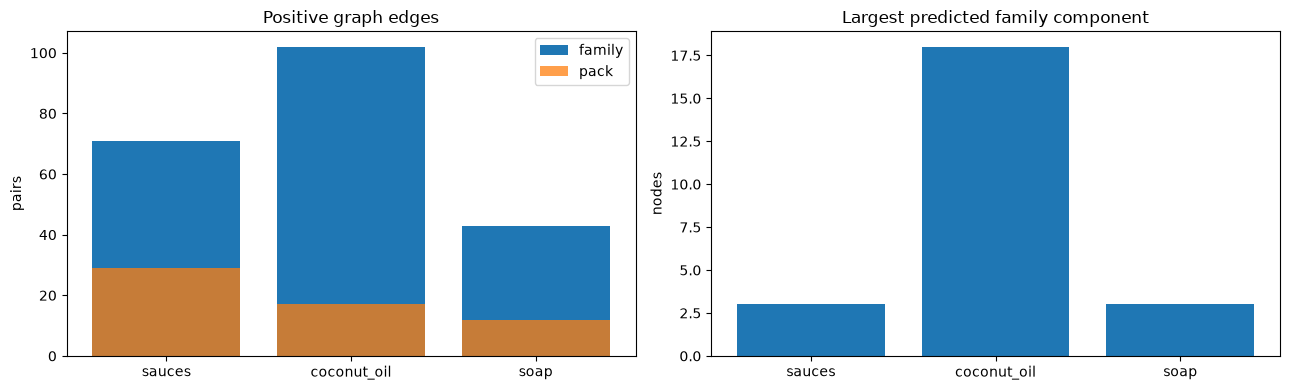

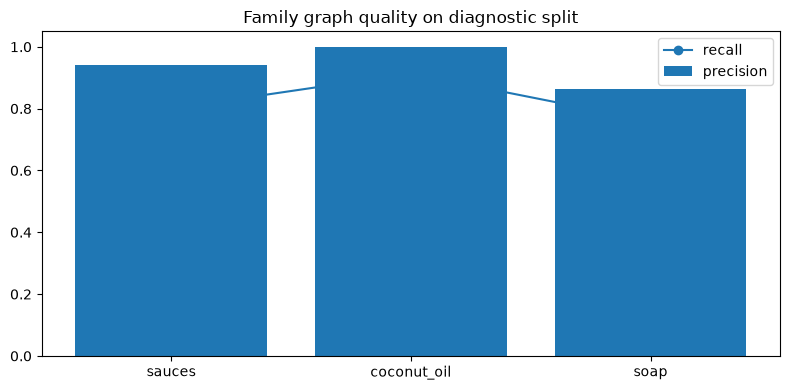

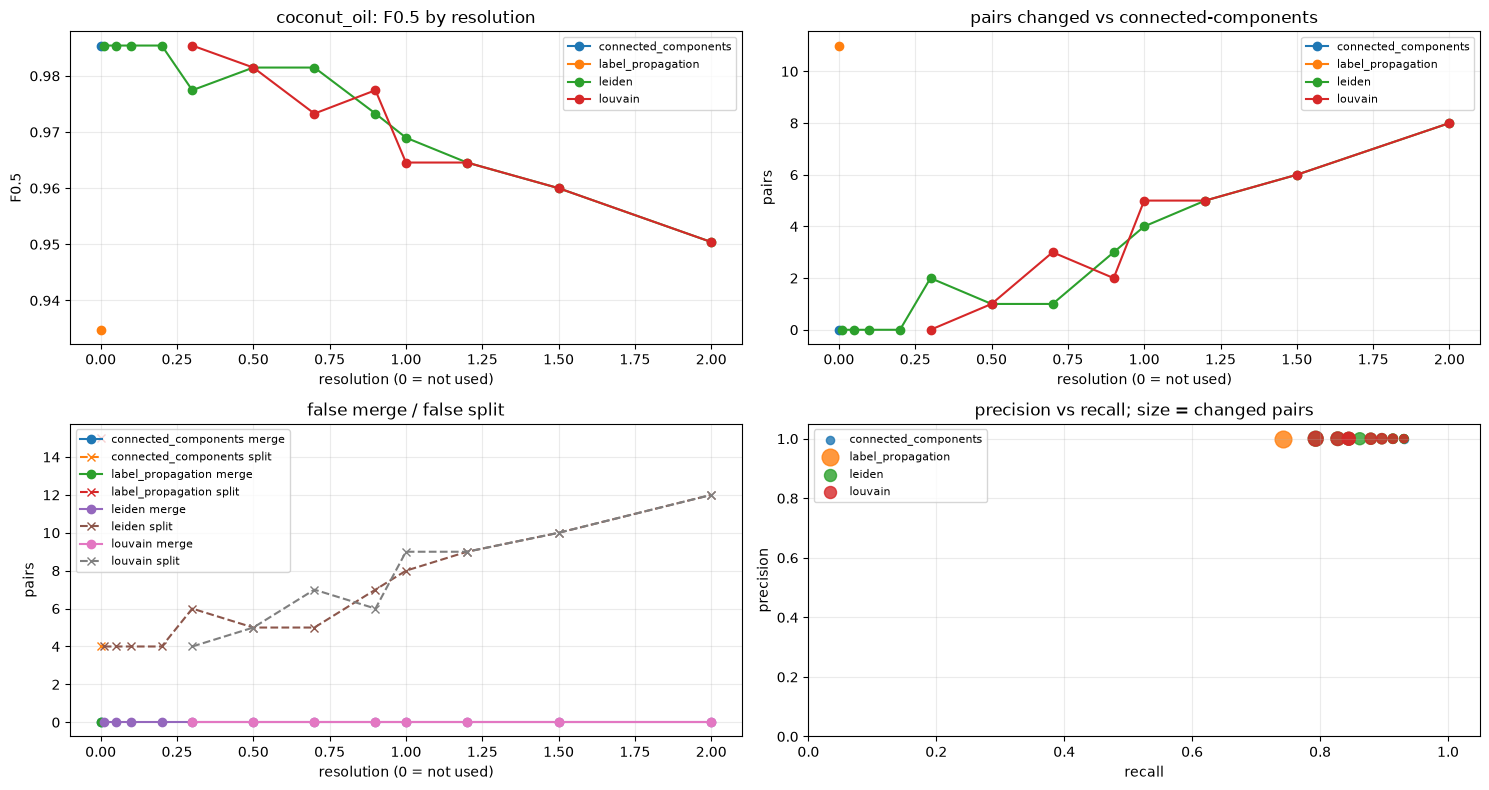

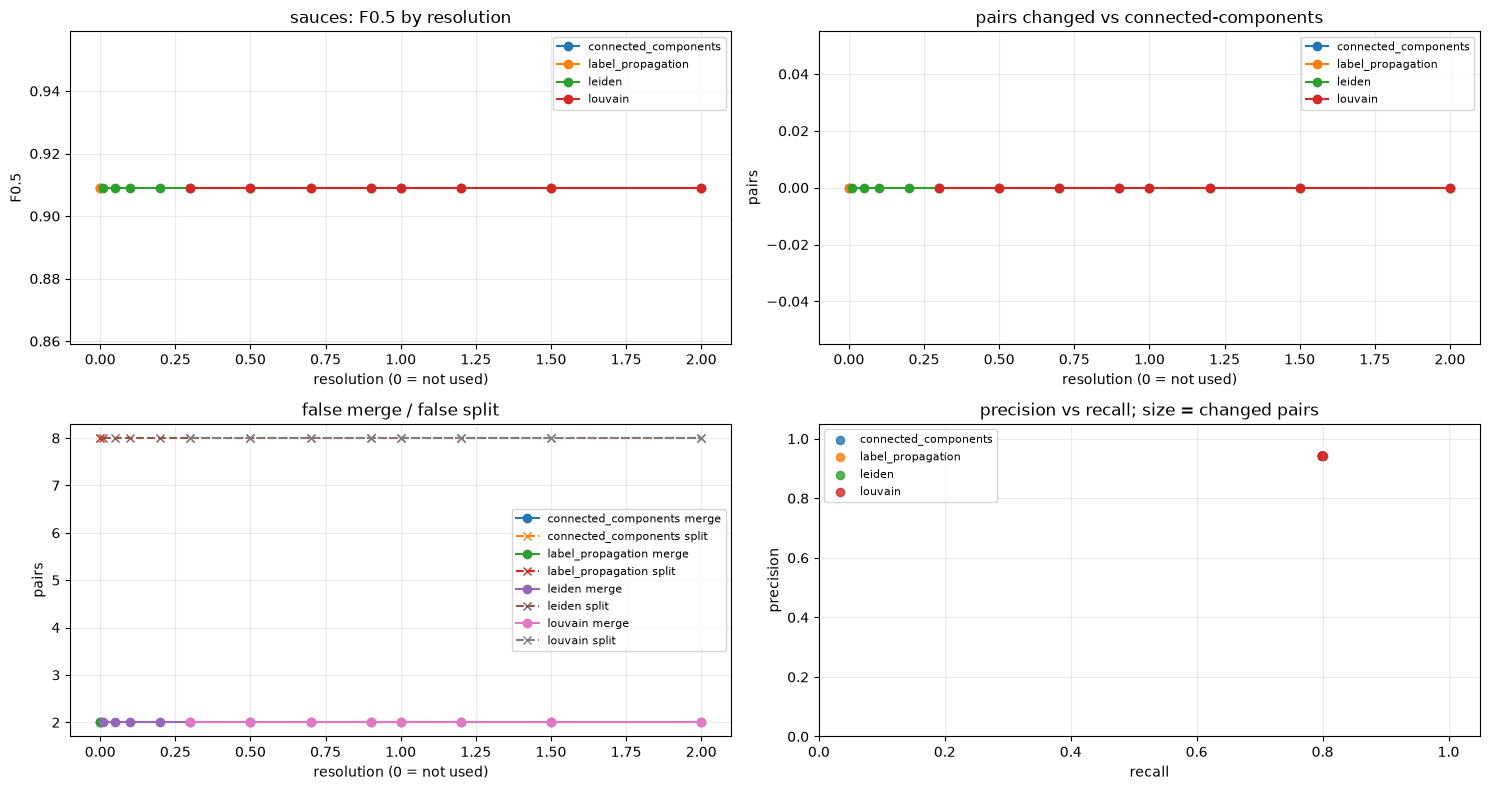

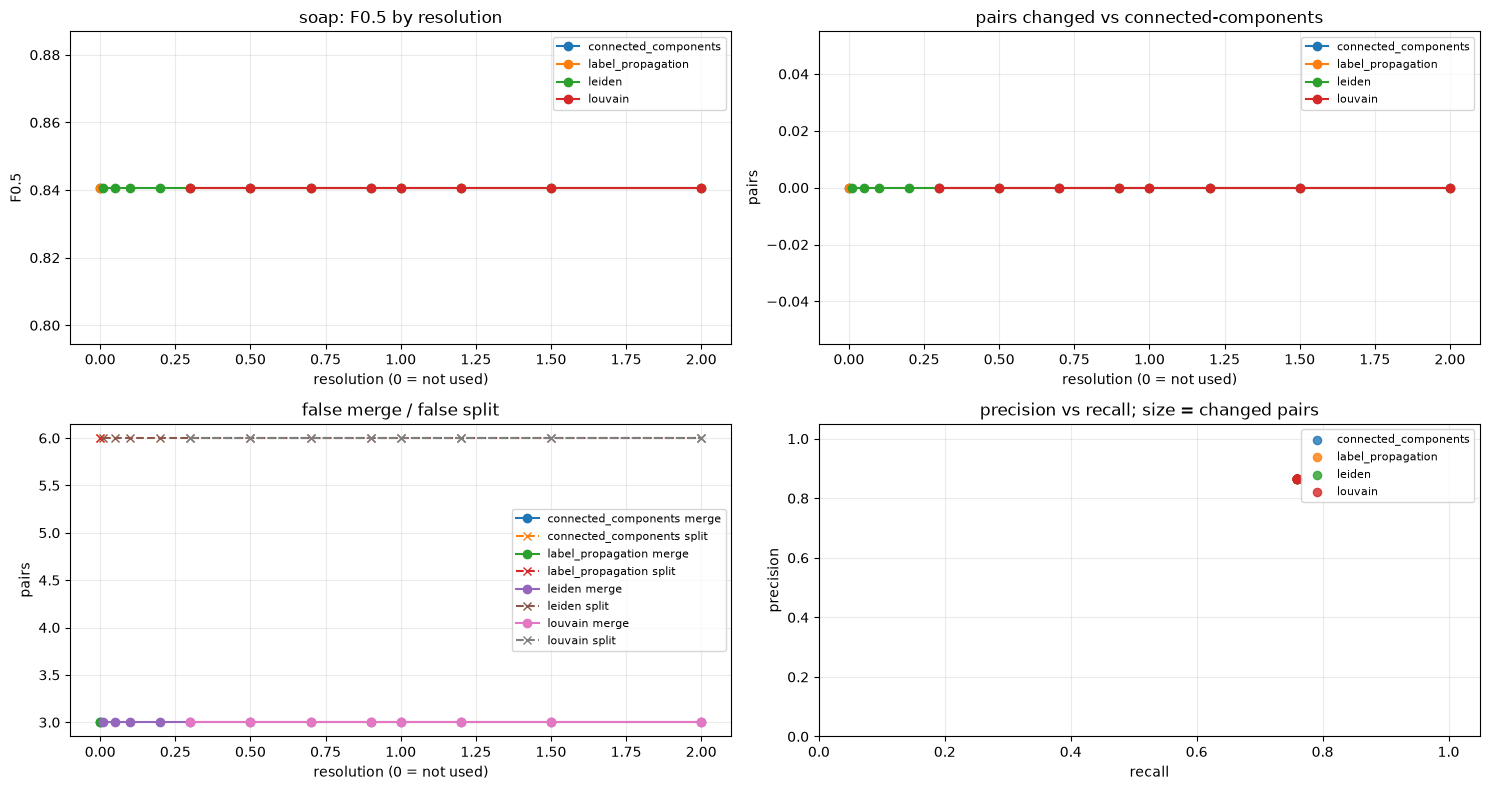

In [45]:
if plt is None:
    print("matplotlib is not available; skipping 2D charts")
elif run_status.empty or not (run_status["status"].astype(str) == "saved").any():
    print("No saved fusion outputs; skipping charts")
else:
    saved_status = run_status[run_status["status"].astype(str).eq("saved")].copy()
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].bar(saved_status["category_run"], saved_status["family_edges"], label="family")
    axes[0].bar(saved_status["category_run"], saved_status["pack_edges"], label="pack", alpha=0.75)
    axes[0].set_title("Positive graph edges")
    axes[0].set_ylabel("pairs")
    axes[0].legend()

    if not component_summary_all.empty:
        max_nodes = component_summary_all[component_summary_all["graph"].eq("pred_family")].copy()
        axes[1].bar(max_nodes["category_run"], max_nodes["max_nodes"])
    axes[1].set_title("Largest predicted family component")
    axes[1].set_ylabel("nodes")
    plt.tight_layout()
    plt.show()

if not graph_quality.empty and plt is not None:
    metric_frame = graph_quality[graph_quality["scope"].eq("family")].copy()
    if not metric_frame.empty:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.bar(metric_frame["category_run"], metric_frame["precision"], label="precision")
        ax.plot(metric_frame["category_run"], metric_frame["recall"], marker="o", label="recall")
        ax.set_ylim(0, 1.05)
        ax.set_title("Family graph quality on diagnostic split")
        ax.legend()
        plt.tight_layout()
        plt.show()

if "algorithm_grid" in globals() and not algorithm_grid.empty and plt is not None:
    error_col = algorithm_grid["error"] if "error" in algorithm_grid.columns else pd.Series("", index=algorithm_grid.index)
    clean_grid = algorithm_grid[error_col.fillna("").astype(str).eq("")].copy()
    for category_run, frame in clean_grid.groupby("category_run"):
        fig, axes = plt.subplots(2, 2, figsize=(15, 8))
        axes = axes.ravel()
        for algorithm, part in frame.groupby("algorithm"):
            part = part.sort_values("resolution")
            x = part["resolution"].fillna(0).astype(float)
            axes[0].plot(x, part["f0_5"], marker="o", label=algorithm)
            axes[1].plot(x, part["pairs_changed_vs_connected"], marker="o", label=algorithm)
            axes[2].plot(x, part["fp_false_merge"], marker="o", label=f"{algorithm} merge")
            axes[2].plot(x, part["fn_false_split"], marker="x", linestyle="--", label=f"{algorithm} split")
            point_sizes = 35 + part["pairs_changed_vs_connected"].fillna(0).astype(float) * 10
            axes[3].scatter(part["recall"], part["precision"], s=point_sizes, label=algorithm, alpha=0.8)
        axes[0].set_title(f"{category_run}: F0.5 by resolution")
        axes[0].set_xlabel("resolution (0 = not used)")
        axes[0].set_ylabel("F0.5")
        axes[1].set_title("pairs changed vs connected-components")
        axes[1].set_xlabel("resolution (0 = not used)")
        axes[1].set_ylabel("pairs")
        axes[2].set_title("false merge / false split")
        axes[2].set_xlabel("resolution (0 = not used)")
        axes[2].set_ylabel("pairs")
        axes[3].set_title("precision vs recall; size = changed pairs")
        axes[3].set_xlabel("recall")
        axes[3].set_ylabel("precision")
        axes[3].set_xlim(0, 1.05)
        axes[3].set_ylim(0, 1.05)
        for ax in axes:
            ax.grid(True, alpha=0.25)
            ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()


## 8. Ошибки и разные фасовки

После построения графа сразу смотрим примеры трёх типов: лишняя склейка разных товаров, пропущенная связь между одинаковыми товарами и один базовый товар с разной фасовкой.

Отдельно выводятся группы риска: это не просто случайные строки, а самые дорогие ложные склейки по весу пары/объёму продаж и score. По ним видно, где ошибка идёт от оценки пары, где от порога решения, а где алгоритм правильно нашёл один продукт, но должен разделить варианты фасовки.


In [46]:
example_cols = [
    "category_run", "split", "score", "same_base_product", "predicted_binary", "same_pack_signature",
    "title_a", "title_b", "brand_a", "brand_b", "unit_amount_a", "unit_amount_b",
    "total_amount_a", "total_amount_b", "multipack_count_a", "multipack_count_b",
    "pair_weight", "fusion_family_id_a", "fusion_family_id_b",
]


def _eval_slice(pair_eval: pd.DataFrame) -> pd.DataFrame:
    if EVAL_SPLIT == "all" or "split" not in pair_eval.columns:
        return pair_eval.copy()
    output = pair_eval[pair_eval["split"].astype(str).eq(EVAL_SPLIT)].copy()
    return output if not output.empty else pair_eval.copy()


def _risk_sorted(frame: pd.DataFrame) -> pd.DataFrame:
    output = frame.copy()
    output["_risk_weight"] = pd.to_numeric(output["pair_weight"], errors="coerce").fillna(1.0) if "pair_weight" in output.columns else 1.0
    output["_risk_score"] = pd.to_numeric(output["score"], errors="coerce").fillna(0.0) if "score" in output.columns else 0.0
    return output.sort_values(["_risk_weight", "_risk_score"], ascending=[False, False])


for category_run, result in fusion_outputs.items():
    if result.get("status") != "saved":
        continue
    pair_eval = result["pair_eval"]
    available_cols = [column for column in example_cols if column in pair_eval.columns]
    eval_pairs = _eval_slice(pair_eval)
    false_links = eval_pairs[~_as_bool(eval_pairs["true_same_family"]) & _as_bool(eval_pairs["pred_same_family"])]
    missed_links = eval_pairs[_as_bool(eval_pairs["true_same_family"]) & ~_as_bool(eval_pairs["pred_same_family"])]
    cut_positive = eval_pairs[
        _as_bool(eval_pairs.get("connected_same_family", pd.Series(False, index=eval_pairs.index)))
        & ~_as_bool(eval_pairs["pred_same_family"])
        & pd.to_numeric(eval_pairs["predicted_binary"], errors="coerce").fillna(0).astype(int).eq(1)
    ]

    print(f"=== {category_run}: top-risk false family links ===")
    _display_table(_risk_sorted(false_links)[available_cols].head(int(MY_RISK_TOP_N)))

    if not false_links.empty and "fusion_family_id_a" in false_links.columns:
        risk_groups = (
            false_links.assign(
                risk_weight=pd.to_numeric(false_links["pair_weight"], errors="coerce").fillna(1.0) if "pair_weight" in false_links.columns else 1.0,
                risk_score=pd.to_numeric(false_links["score"], errors="coerce").fillna(0.0) if "score" in false_links.columns else 0.0,
            )
            .groupby("fusion_family_id_a", dropna=True)
            .agg(false_links=("fusion_family_id_a", "size"), risk_weight=("risk_weight", "sum"), max_score=("risk_score", "max"), example_a=("title_a", "first"), example_b=("title_b", "first"))
            .sort_values(["risk_weight", "false_links", "max_score"], ascending=[False, False, False])
            .reset_index()
        )
        print(f"=== {category_run}: risky predicted families ===")
        _display_table(risk_groups.head(int(MY_RISK_TOP_N)))

    print(f"=== {category_run}: missed family links ===")
    _display_table(_risk_sorted(missed_links)[available_cols].head(int(MY_RISK_TOP_N)))

    print(f"=== {category_run}: positive links cut by selected graph algorithm ===")
    _display_table(_risk_sorted(cut_positive)[available_cols].head(int(MY_RISK_TOP_N)))

    print(f"=== {category_run}: same family, different pack ===")
    _display_table(pair_eval[_as_bool(pair_eval["pred_same_family"]) & ~_as_bool(pair_eval["pred_same_pack"])][available_cols].head(int(MY_RISK_TOP_N)))


=== sauces: top-risk false family links ===


,category_run,split,score,same_base_product,predicted_binary,same_pack_signature,title_a,title_b,brand_a,brand_b,unit_amount_a,unit_amount_b,total_amount_a,total_amount_b,multipack_count_a,multipack_count_b,pair_weight,fusion_family_id_a,fusion_family_id_b
170,sauces,test,0.998964,0,1,False,"Aroy-D соус ""Кисло-сладкий/Sweet and sour sauce"", 215 гр","Aroy-D соус ""Кисло-сладкий/Sweet and sour sauce"", 215 гр (х2шт)",aroy-d,aroy-d,0.215,0.215,0.215,0.43,1.0,2.0,5.402677,156,156
239,sauces,test,0.917274,0,1,True,Соус Samyang Buldak со вкусом острой курицы 2x spicy ЭКСТРЕМАЛЬНО ОСТРЫЙ 200г,Соус со вкусом острой курицы Original Spicy Buldak 200 г,samyang,samyang,0.200,0.200,0.200,0.20,1.0,1.0,4.394449,32,32


=== sauces: risky predicted families ===


,fusion_family_id_a,false_links,risk_weight,max_score,example_a,example_b
0,156,1,5.402677,0.998964,"Aroy-D соус ""Кисло-сладкий/Sweet and sour sauce"", 215 гр","Aroy-D соус ""Кисло-сладкий/Sweet and sour sauce"", 215 гр (х2шт)"
1,32,1,4.394449,0.917274,Соус Samyang Buldak со вкусом острой курицы 2x spicy ЭКСТРЕМАЛЬНО ОСТРЫЙ 200г,Соус со вкусом острой курицы Original Spicy Buldak 200 г


=== sauces: missed family links ===


...

,category_run,split,score,same_base_product,predicted_binary,same_pack_signature,title_a,title_b,brand_a,brand_b,unit_amount_a,unit_amount_b,total_amount_a,total_amount_b,multipack_count_a,multipack_count_b,pair_weight,fusion_family_id_a,fusion_family_id_b
186,soap,test,0.264044,1,0,False,Мыло банное НМЖК твердое кусковое для бани и сауны (12шт по 180г),"НМЖК Мыло туалетное твердое Банное для рук и тела, 180гр*1шт",нмжк,нмжк,0.180,0.180,2.160,0.180,12.0,1.0,7.652546,205,222
199,soap,test,0.794647,1,0,False,Мыло увлажняющее Красота и уход 6х135 г,"Мыло туалетное твердое Красота и Уход 4 штуки, 135г",dove,dove,0.135,0.135,0.810,0.135,6.0,1.0,7.254885,278,338
188,soap,test,0.001974,1,0,True,"Мыло Сладкая Жизнь: Сладости, 100 г","Мыло Ароматы Тропиков: Лайм, 100 г",florinda,florinda,0.100,0.100,0.100,0.100,1.0,1.0,5.262690,271,274
194,soap,test,0.028260,1,0,False,"Royal Мыло твердое Оливковый соблазн, 140 г",Мыло Фруктовое твердое 6 шт по 140 г,royal,alviero,0.140,0.140,0.140,0.840,1.0,6.0,4.844187,91,214
198,soap,test,0.657721,1,0,False,"Camay Мыло туалетное Romantique, с ароматом французской розы, 85 гр /","Мыло кусковое туалетное Camay Romantique, бумажная обертка, 85г (67435961), 48шт.",camay,camay,0.085,0.085,0.085,4.080,1.0,48.0,4.025352,24,180
206,soap,test,0.003967,1,0,True,"Весна Крем-мыло жидкое Жасмин и кокосовое молочко, 280 г",Весна Жидкое крем-мыло Алоэ и овсяное молочко 280 гр,NaN,весна,0.280,0.280,0.280,0.280,1.0,1.0,3.931826,57,252


=== soap: positive links cut by selected graph algorithm ===


,category_run,split,score,same_base_product,predicted_binary,same_pack_signature,title_a,title_b,brand_a,brand_b,unit_amount_a,unit_amount_b,total_amount_a,total_amount_b,multipack_count_a,multipack_count_b,pair_weight,fusion_family_id_a,fusion_family_id_b


=== soap: same family, different pack ===


,category_run,split,score,same_base_product,predicted_binary,same_pack_signature,title_a,title_b,brand_a,brand_b,unit_amount_a,unit_amount_b,total_amount_a,total_amount_b,multipack_count_a,multipack_count_b,pair_weight,fusion_family_id_a,fusion_family_id_b
82,soap,dev,0.952440,1,1,False,"Твердое крем-мыло EXXE / Экссе косметическое Роза и Грейпфрут, 1шт. 90г / для бани и душа",Туалетное крем-мыло Роза и грейпфрут 4шт х 70г,exxe,exxe,0.090,0.070,0.090,0.28,1.0,4.0,5.288267,118,118
83,soap,dev,0.998193,1,1,False,"Мыло туалетное НЕВСКАЯ КОСМЕТИКА Вазелиновое, 90 г","Туалетное мыло Вазелиновое, 90г х 12шт",невская косметика,невская косметика,0.090,0.090,0.090,1.08,1.0,12.0,4.804021,43,43
89,soap,dev,0.995420,1,1,False,Floresan / Флоресан Мыло натуральное таежное Зеленое для бани и душа 450мл / гигиена и уход (комплект из 3 шт),"Мыло Floresan Зеленое, для бани и душа, уход за телом и волосами, натуральное таежное, 450 мл (Ф-38 М)",floresan,floresan,0.450,0.450,1.350,0.45,3.0,1.0,6.926577,53,53
90,soap,dev,0.987234,1,1,False,"Особая серия Мыло жидкое в мягкой упаковке, овсяное молочко 500 мл",Особая Серия Жидкое крем-мыло увлажняющее Овсяное молочко нежное питательное с овсяным молочком в мягкой упаковке 500мл (комплект из 4 шт),особая серия,особая серия,0.500,0.500,0.500,2.00,1.0,4.0,5.017280,248,248
91,soap,dev,0.988285,1,1,False,"La Fabrique, Жидкое мыло для рук парфюмированное с ароматом табак вишня и табак ваниль, подарочный набор для женщин, 600 мл","La Fabrique, Жидкое мыло для рук и тела с дозатором парфюмированное, аромат Табак и вишня, 300 мл",la fabrique,la fabrique,0.600,0.300,0.600,0.30,1.0,1.0,7.681560,110,110
92,soap,dev,0.992112,1,1,False,"Рецепты бабушки Агафьи Черное Мыло для бани густое для волос и тела, набор 2 шт х 500 мл",Мыло для бани Черное Агафьи для волос и тела 500 мл,рецепты бабушки агафьи,рецепты бабушки агафьи,0.500,0.500,1.000,0.50,2.0,1.0,9.009570,55,55
94,soap,dev,0.990017,1,1,False,"Мыло кусковое туалетное Краснодарское Ландыш 75 г, 15 шт","Мыло туалетное натуральное Краснодарское Ландыш 75 г, 40 шт",меридиан,меридиан,0.075,0.075,1.125,3.00,15.0,40.0,3.784190,219,219
95,soap,dev,0.987939,1,1,False,"Свобода Мыло детское твердое кусковое с оливковым молочком ""Тик-Так"", набор 90гр*3шт","Мыло Тик-Так нейтральное детское с оливковым молочком, 6 штук по 90г Свобода",свобода,свобода,0.090,0.090,0.270,0.54,3.0,6.0,7.094235,109,109
96,soap,dev,0.988380,1,1,False,Крем-мыло жидкое Дав Красота и уход 250мл,Бесульфатное крем-мыло Красота и уход 4шт х 135 г,дав,дав,0.250,0.135,0.250,0.54,1.0,4.0,6.423247,217,217
97,soap,dev,0.993763,1,1,False,Ушастый нянь Крем-мыло Алоэ-Вера 90 гр 3шт,"Детское крем-мыло с алоэ вера 90г, 6шт",ушастый нянь,ушастый нянь,0.090,0.090,0.270,0.54,3.0,6.0,4.700480,262,262


## 9. 2D-карта проблемной компоненты

Эта карта показывает одну выбранную компоненту крупным планом. Точки — SKU, линии — связи между ними. Цвет линии показывает смысл ошибки: зелёная связь подтверждена разметкой, красная выглядит как ложная склейка, оранжевая — пропущенная связь.

В отличие от 3D-карты ниже, это диагностический вид: его задача — быстро открыть конкретную группу и понять, почему graph grouping сработал или ошибся.


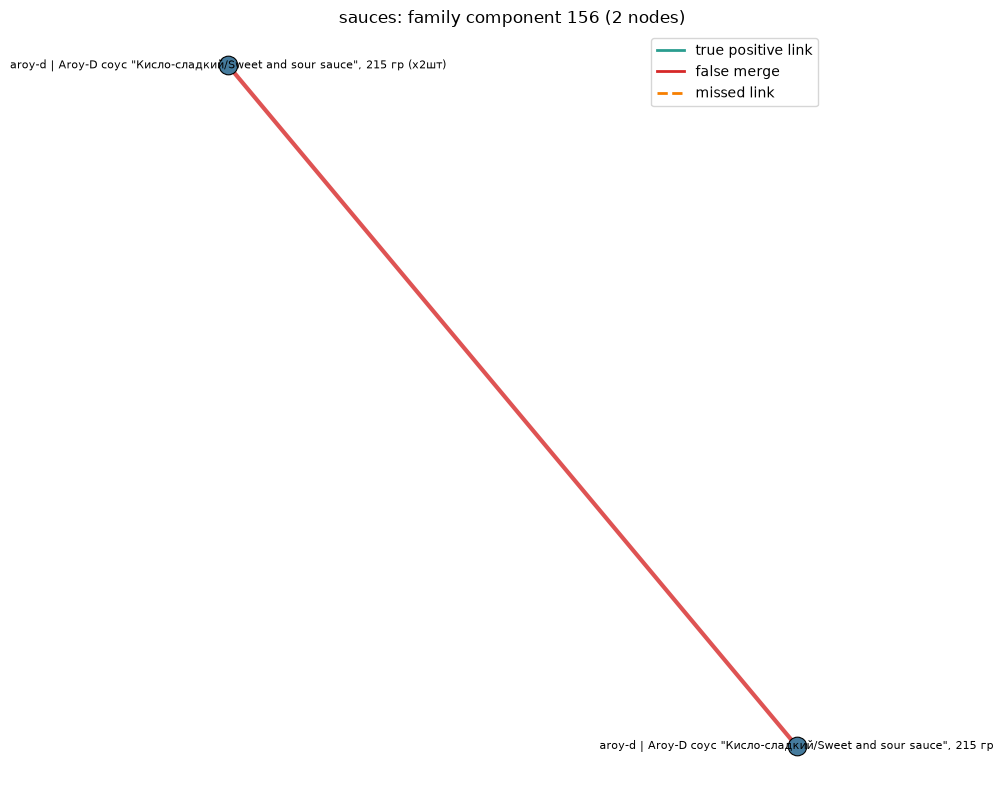

In [47]:
def _pick_2d_category(outputs: dict[str, dict[str, Any]], requested: str) -> str | None:
    saved = [key for key, value in outputs.items() if value.get("status") == "saved" and not value.get("components", pd.DataFrame()).empty]
    if not saved:
        return None
    if requested != "auto" and requested in saved:
        return requested
    for key in saved:
        pair_eval = _eval_slice(outputs[key]["pair_eval"])
        if (~_as_bool(pair_eval["true_same_family"]) & _as_bool(pair_eval["pred_same_family"])).any():
            return key
    return saved[0]


def _pick_component_for_2d(components: pd.DataFrame, pair_eval: pd.DataFrame, *, component_col: str) -> object | None:
    false_links = pair_eval[~_as_bool(pair_eval["true_same_family"]) & _as_bool(pair_eval["pred_same_family"])]
    left_col = f"{component_col}_a"
    if left_col in false_links.columns and false_links[left_col].notna().any():
        return false_links[left_col].value_counts().index[0]
    sizes = component_size_summary(components[["node_id", component_col]].dropna(), component_col=component_col)
    sizes = sizes[sizes["nodes"].gt(1)]
    return None if sizes.empty else sizes.iloc[0][component_col]


def _draw_2d_component(category_run: str, result: dict[str, Any], *, graph: str, max_nodes: int) -> None:
    if plt is None:
        print("matplotlib is not available; skipping 2D component view")
        return
    components = result["components"]
    pair_eval = _eval_slice(result["pair_eval"])
    component_col = "fusion_pack_id" if str(graph).lower() == "pack" else "fusion_family_id"
    same_col = "pred_same_pack" if str(graph).lower() == "pack" else "pred_same_family"
    component_id = _pick_component_for_2d(components, pair_eval, component_col=component_col)
    if component_id is None:
        print(f"{category_run}: no multi-node component for 2D view")
        return
    nodes = components[components[component_col].eq(component_id)].copy().head(max_nodes)
    node_ids = set(nodes["node_id"].astype(str))
    n = len(nodes)
    radius = 1.0 + math.log1p(max(n, 1))
    coords = {}
    for index, row in enumerate(nodes.sort_values("node_id").itertuples(index=False)):
        angle = 2 * math.pi * index / max(n, 1)
        coords[str(row.node_id)] = (radius * math.cos(angle), radius * math.sin(angle))
    edge_rows = pair_eval[pair_eval["raw_record_id_a"].astype(str).isin(node_ids) & pair_eval["raw_record_id_b"].astype(str).isin(node_ids)].copy()
    if same_col in edge_rows.columns:
        edge_rows = edge_rows[_as_bool(edge_rows[same_col]) | _as_bool(edge_rows.get("true_same_family", pd.Series(False, index=edge_rows.index)))]
    fig, ax = plt.subplots(figsize=(10, 8))
    for row in edge_rows.itertuples(index=False):
        left = coords.get(str(row.raw_record_id_a))
        right = coords.get(str(row.raw_record_id_b))
        if left is None or right is None:
            continue
        values = row._asdict()
        pred_same = bool(values.get(same_col, False))
        true_same = bool(values.get("true_same_family", False))
        if pred_same and true_same:
            color, width, style = "#2a9d8f", 2.2, "-"
        elif pred_same and not true_same:
            color, width, style = "#d62828", 3.0, "-"
        elif true_same and not pred_same:
            color, width, style = "#f77f00", 2.2, "--"
        else:
            color, width, style = "0.75", 1.0, ":"
        ax.plot([left[0], right[0]], [left[1], right[1]], color=color, linewidth=width, linestyle=style, alpha=0.8)
    xs = [coords[str(node_id)][0] for node_id in nodes["node_id"].astype(str)]
    ys = [coords[str(node_id)][1] for node_id in nodes["node_id"].astype(str)]
    ax.scatter(xs, ys, s=180, c="#457b9d", edgecolor="black", linewidth=0.8, zorder=3)
    for row in nodes.itertuples(index=False):
        x, y = coords[str(row.node_id)]
        label_parts = [str(part) for part in [getattr(row, 'brand', ''), getattr(row, 'title', '')] if pd.notna(part) and str(part).strip()]
        label = ' | '.join(label_parts)[:90]
        ax.text(x, y, label, fontsize=8, ha="center", va="center", zorder=4)
    ax.set_title(f"{category_run}: {graph} component {component_id} ({n} nodes)")
    ax.axis("off")
    ax.plot([], [], color="#2a9d8f", linewidth=2, label="true positive link")
    ax.plot([], [], color="#d62828", linewidth=2, label="false merge")
    ax.plot([], [], color="#f77f00", linewidth=2, linestyle="--", label="missed link")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


selected_2d_category = _pick_2d_category(fusion_outputs, str(MY_2D_CATEGORY_RUN))
if selected_2d_category is None:
    print("No saved fusion outputs for 2D graph")
else:
    _draw_2d_component(selected_2d_category, fusion_outputs[selected_2d_category], graph=MY_2D_GRAPH, max_nodes=int(MY_2D_MAX_NODES))


## 10. 3D-карта всех компонент

Эта карта показывает не одну случайную маленькую компоненту, а все выбранные graph components. По умолчанию `MY_3D_CATEGORY_RUN = "all"`, поэтому в один обзор попадают `sauces`, `coconut_oil` и `soap`.

Каждая component получает свой маленький круг узлов, а категории разнесены по пространству. Так видно общую форму результата: где много одиночек, где есть плотные группы, где крупные компоненты и сколько реальных positive-рёбер между точками. Это не заменяет метрики, но хорошо показывает, как именно граф разложился.


In [48]:
def _component_col_for_graph(graph: str) -> tuple[str, str]:
    graph = str(graph).strip().lower()
    if graph == "pack":
        return "fusion_pack_id", "pred_same_pack"
    return "fusion_family_id", "pred_same_family"


def _selected_3d_outputs(outputs: dict[str, dict[str, Any]], requested: str, *, graph: str) -> dict[str, dict[str, Any]]:
    saved = {key: value for key, value in outputs.items() if value.get("status") == "saved" and not value.get("components", pd.DataFrame()).empty}
    if not saved:
        return {}
    requested = str(requested).strip().lower()
    if requested == "all":
        return saved
    if requested != "auto" and requested in saved:
        return {requested: saved[requested]}
    component_col, _ = _component_col_for_graph(graph)
    best_key = None
    best_size = -1
    for key, value in saved.items():
        components = value.get("components", pd.DataFrame())
        if component_col not in components.columns:
            continue
        sizes = component_size_summary(components[["node_id", component_col]].dropna(), component_col=component_col)
        if not bool(MY_3D_INCLUDE_SINGLETONS):
            sizes = sizes[sizes["nodes"].gt(1)]
        size = int(sizes["nodes"].max()) if not sizes.empty else 0
        if size > best_size:
            best_key, best_size = key, size
    return {best_key: saved[best_key]} if best_key else saved


def _component_candidates_for_3d(outputs: dict[str, dict[str, Any]], *, graph: str) -> pd.DataFrame:
    component_col, _ = _component_col_for_graph(graph)
    rows: list[dict[str, object]] = []
    for category_run, result in _selected_3d_outputs(outputs, str(MY_3D_CATEGORY_RUN), graph=graph).items():
        components = result.get("components", pd.DataFrame())
        if components.empty or component_col not in components.columns:
            continue
        sizes = component_size_summary(components[["node_id", component_col]].dropna(), component_col=component_col)
        multi = sizes[sizes["nodes"].gt(1)].copy()
        selected = sizes if bool(MY_3D_INCLUDE_SINGLETONS) else multi
        rows.append({
            "category_run": category_run,
            "graph": graph,
            "components_total": int(len(sizes)),
            "components_selected": int(len(selected)),
            "multi_node_components": int(len(multi)),
            "largest_component_nodes": int(sizes["nodes"].max()) if not sizes.empty else 0,
            "nodes_selected_for_3d": int(selected["nodes"].sum()) if not selected.empty else 0,
            "top_component_ids": ", ".join(map(str, selected.head(12)[component_col].tolist())),
        })
    return pd.DataFrame(rows).sort_values(["largest_component_nodes", "nodes_selected_for_3d"], ascending=[False, False]) if rows else pd.DataFrame()


def _to_optional_int(value: object) -> int | None:
    if value is None:
        return None
    try:
        return int(value)
    except (TypeError, ValueError):
        return None


def _build_all_components_3d_layout(outputs: dict[str, dict[str, Any]], *, graph: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    component_col, same_col = _component_col_for_graph(graph)
    selected_outputs = _selected_3d_outputs(outputs, str(MY_3D_CATEGORY_RUN), graph=graph)
    max_components = _to_optional_int(MY_3D_MAX_COMPONENTS)
    max_nodes = _to_optional_int(MY_3D_MAX_NODES)
    node_frames: list[pd.DataFrame] = []
    edge_frames: list[pd.DataFrame] = []

    for category_index, (category_run, result) in enumerate(sorted(selected_outputs.items())):
        components = result.get("components", pd.DataFrame()).copy()
        pair_eval = result.get("pair_eval", pd.DataFrame()).copy()
        if components.empty or component_col not in components.columns:
            continue
        sizes = component_size_summary(components[["node_id", component_col]].dropna(), component_col=component_col)
        if not bool(MY_3D_INCLUDE_SINGLETONS):
            sizes = sizes[sizes["nodes"].gt(1)]
        if max_components is not None:
            sizes = sizes.head(max_components)
        if sizes.empty:
            continue
        nodes = components[components[component_col].isin(set(sizes[component_col]))].copy()
        nodes = nodes.merge(sizes, on=component_col, how="left")
        nodes = nodes.sort_values(["nodes", component_col, "node_id"], ascending=[False, True, True]).copy()
        if max_nodes is not None:
            remaining = max_nodes - sum(len(frame) for frame in node_frames)
            if remaining <= 0:
                break
            nodes = nodes.head(remaining)
        node_ids = set(nodes["node_id"].astype(str))
        if not node_ids:
            continue

        selected_component_ids = list(dict.fromkeys(nodes[component_col].tolist()))
        grid_cols = max(1, math.ceil(math.sqrt(len(selected_component_ids))))
        spacing = 4.8
        category_offset_x = category_index * (grid_cols * spacing + 8.0)
        category_offset_y = 0.0
        coords = []
        for component_rank, component_id in enumerate(selected_component_ids):
            group = nodes[nodes[component_col].eq(component_id)].copy()
            group = group.sort_values(["sales_volume", "node_id"], ascending=[False, True]) if "sales_volume" in group.columns else group.sort_values("node_id")
            n = max(len(group), 1)
            center_x = category_offset_x + (component_rank % grid_cols) * spacing
            center_y = category_offset_y + (component_rank // grid_cols) * spacing
            radius = 0.0 if n == 1 else min(1.7, 0.45 + math.log1p(n) * 0.28)
            for local_index, (_, row) in enumerate(group.iterrows()):
                angle = 2 * math.pi * local_index / n if n > 1 else 0.0
                sales = pd.to_numeric(pd.Series([row.get("sales_volume")]), errors="coerce").fillna(0).iloc[0]
                total_amount = pd.to_numeric(pd.Series([row.get("total_amount")]), errors="coerce").fillna(0).iloc[0]
                z = math.log1p(float(sales)) if sales > 0 else float(category_index) * 0.15
                coords.append({
                    "category_run": category_run,
                    "node_id": str(row["node_id"]),
                    "component_id": component_id,
                    "component_nodes": int(row["nodes"]),
                    "x": center_x + radius * math.cos(angle),
                    "y": center_y + radius * math.sin(angle),
                    "z": z,
                    "marker_size": max(4.0, min(20.0, 4.0 + math.log1p(float(sales)) * 1.5 + math.log1p(float(row["nodes"])) * 1.2)),
                    "label": f"{row.get('brand', '')} | {row.get('title', '')}"[:220],
                    "sales_volume": sales,
                    "total_amount": total_amount,
                    "pack_id": row.get("fusion_pack_id"),
                    "family_id": row.get("fusion_family_id"),
                })
        layout = pd.DataFrame(coords)
        if layout.empty:
            continue
        node_frames.append(layout)

        coord_map = layout.set_index("node_id")[["x", "y", "z", "category_run"]].to_dict("index")
        if same_col in pair_eval.columns:
            edge_rows = pair_eval[_as_bool(pair_eval[same_col])].copy()
        else:
            edge_rows = pair_eval.copy()
        edge_rows = edge_rows[
            edge_rows["raw_record_id_a"].astype(str).isin(node_ids)
            & edge_rows["raw_record_id_b"].astype(str).isin(node_ids)
        ].copy()
        edges = []
        for row in edge_rows[["raw_record_id_a", "raw_record_id_b"]].drop_duplicates().itertuples(index=False):
            left = coord_map.get(str(row.raw_record_id_a))
            right = coord_map.get(str(row.raw_record_id_b))
            if left and right:
                edges.append({
                    "category_run": category_run,
                    "x": [left["x"], right["x"], None],
                    "y": [left["y"], right["y"], None],
                    "z": [left["z"], right["z"], None],
                })
        if edges:
            edge_frames.append(pd.DataFrame(edges))

    node_layout = pd.concat(node_frames, ignore_index=True) if node_frames else pd.DataFrame()
    edge_layout = pd.concat(edge_frames, ignore_index=True) if edge_frames else pd.DataFrame()
    return node_layout, edge_layout


component_candidates_3d = _component_candidates_for_3d(fusion_outputs, graph=MY_3D_GRAPH)
if component_candidates_3d.empty:
    print("No components available for 3D graph")
else:
    _display_table(component_candidates_3d, title="3D component coverage")

all_graph_nodes, all_graph_edges = _build_all_components_3d_layout(fusion_outputs, graph=MY_3D_GRAPH)
print(f"3D graph scope={MY_3D_CATEGORY_RUN}, graph={MY_3D_GRAPH}, nodes={len(all_graph_nodes)}, edges={len(all_graph_edges)}")

if all_graph_nodes.empty:
    print("No nodes to visualize")
elif go is not None:
    edge_x, edge_y, edge_z = [], [], []
    for row in all_graph_edges.itertuples(index=False):
        edge_x.extend(row.x)
        edge_y.extend(row.y)
        edge_z.extend(row.z)
    fig = go.Figure()
    if edge_x:
        fig.add_trace(go.Scatter3d(
            x=edge_x,
            y=edge_y,
            z=edge_z,
            mode="lines",
            line=dict(color="rgba(110,110,110,0.35)", width=2),
            hoverinfo="skip",
            name="positive edges",
        ))
    symbols = ["circle", "diamond", "square", "cross", "x"]
    for symbol_index, (category_run, nodes_part) in enumerate(all_graph_nodes.groupby("category_run", sort=True)):
        fig.add_trace(go.Scatter3d(
            x=nodes_part["x"],
            y=nodes_part["y"],
            z=nodes_part["z"],
            mode="markers",
            text=nodes_part["label"],
            hovertemplate=(
                "<b>%{text}</b><br>category=%{customdata[0]}<br>component=%{customdata[1]}<br>"
                "component_nodes=%{customdata[2]}<br>family=%{customdata[3]}<br>pack=%{customdata[4]}<br>"
                "sales=%{customdata[5]}<br>total_amount=%{customdata[6]}<extra></extra>"
            ),
            customdata=nodes_part[["category_run", "component_id", "component_nodes", "family_id", "pack_id", "sales_volume", "total_amount"]],
            marker=dict(
                size=nodes_part["marker_size"],
                color=nodes_part["component_nodes"],
                colorscale="Turbo",
                opacity=0.86,
                symbol=symbols[symbol_index % len(symbols)],
                colorbar=dict(title="component<br>size") if symbol_index == 0 else None,
                showscale=symbol_index == 0,
            ),
            name=category_run,
        ))
    fig.update_layout(
        title=f"3D {MY_3D_GRAPH} graph components — scope={MY_3D_CATEGORY_RUN}",
        height=820,
        scene=dict(
            xaxis_title="component grid x",
            yaxis_title="component grid y",
            zaxis_title="log sales / category offset",
        ),
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
        margin=dict(l=0, r=0, t=70, b=0),
    )
    fig.show()
elif plt is not None:
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection="3d")
    for row in all_graph_edges.itertuples(index=False):
        ax.plot(row.x[:2], row.y[:2], row.z[:2], color="0.65", linewidth=0.8, alpha=0.4)
    for category_run, nodes_part in all_graph_nodes.groupby("category_run", sort=True):
        ax.scatter(
            nodes_part["x"],
            nodes_part["y"],
            nodes_part["z"],
            s=nodes_part["marker_size"] * 8,
            alpha=0.86,
            label=category_run,
        )
    ax.set_title(f"3D {MY_3D_GRAPH} graph components — scope={MY_3D_CATEGORY_RUN}")
    ax.set_xlabel("component grid x")
    ax.set_ylabel("component grid y")
    ax.set_zlabel("log sales / category offset")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    _display_table(all_graph_nodes.head(200), title="3D node layout fallback")


,category_run,graph,components_total,components_selected,multi_node_components,largest_component_nodes,nodes_selected_for_3d,top_component_ids
0,sauces,family,514,514,68,3,585,"6, 197, 316, 7, 16, 18, 20, 23, 31, 32, 38, 39"


3D graph scope=sauces, graph=family, nodes=585, edges=71


## 11. Итоговые выводы

После этого шага у нас есть готовый исследовательский результат для дедупликации SKU: сохранены группы базовых товаров, отдельно выделены фасовки, посчитана диагностика качества и собраны примеры спорных решений.

Основной вывод по graph comparison теперь читается через таблицы: если `pairs_changed_vs_connected = 0`, алгоритм не поменял решения на текущем размеченном срезе, поэтому одинаковые метрики ожидаемы. 3D-карта показывает все выбранные компоненты, чтобы было видно общую структуру графа, а не только один маленький фрагмент.

Следующий ноутбук `05_grouped_sku_demo.ipynb` показывает тот же подход на небольшом живом срезе из DuckDB. Он нужен как витрина: от сырых карточек товара до понятного дерева склеенных SKU и агрегатов по группе.
